### **Import libraries**

In [ ]:
#Import necessary libraries
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from datasets import Dataset

In [ ]:
#Libraries below are used in emotion classification model
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from transformers import pipeline

In [ ]:
#Visualization
from wordcloud import WordCloud, STOPWORDS
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr

# **How does combining reviews sentiment and star ratings improve book recommendations?**

# **Hypothesis/analysis goal (Ask)**




**Hypothesis and analysis goal:** Customer dependence on star ratings alone often leads to unsatisfactory book choices, as only numerical star ratings fail to capture the emotional depth or functionality of written reviews. In this project, we want to investigate whether integrating emotional and sentiment information extracted from customer review text can generate more meaningful book rankings which allows book recommendations to be more customized for individual customers. To make this scope of this project further refined, we will be focusing on Amazon book reviews.


**Question:** How does combining reviews sentiment and star ratings improve book recommendations?

**Stakeholders:** This project will benefit multiple stakeholders: Sellers can obtain valuable insights into how viewers regard their books. This information will help them to improve their marketing strategies. Customers will also be better prepared to buy books with more confidence and Amazon can boost user engagement through a more precise book recommendation system.

**Type of analysis and quality metrics:** To evaluate this, descriptive analysis will be used to investigate the relationships between star ratings, review sentiment and length, and emotional cues. Model quality will be measured using ranking accuracy, correlation strength, and improvements in review helpfulness. Prescriptive analysis will then be applied to design a new recommendation framework that ranks books based on the integration of ratings with sentiment features. Additionally, diagnostic analysis will conducted to examine relationships and dependencies between variables such as star ratings, sentiment, and review helpfulness. Hypothesis testing using a Mann-Whitney U test will also validate if high-sentiment reviews are significantly more helpful than low-sentiment reviews within the same rating range. After which, predictive analysis will be used to compare the effectiveness of the new system with the existing ratings-only method to demonstrate improvements in user relevance and decision-making.  

# **Data source identification and exploration (Prepare)**

**Requirement analysis.**

To tackle this problem, we require datasets of Amazon book reviews that includes star ratings, review text and review length. It is necessary to include the review text so that descriptive analysis can be performed. It will also enable the extraction of sentiment and emotional undertones using natural language and processing methods.

The dataset should also include books from a broad spectrum of book genres and different levels of popularity. This would enable diverse customer perspectives and review behaviors to be captured. Moreover, aggregate review content per book is enough for generating rankings to help in sentiment and emotion extraction. Hence, descriptive analysis of the review texts will explore relationships between star ratings, review lengths and different sentiments.


**List of considered datasets:** In the following, we outline several sources we considered and explored and justify the final source selection (marked with an ***)

**Book Reviews (review text available):**

- [(DS1) Amazon Books Reviews - Rating.csv ***](https://www.kaggle.com/datasets/mohamedbakhet/amazon-books-reviews?select=Books_rating.csv)
- [(DS2) Top 100 Bestselling Book Reviews on Amazon](https://www.kaggle.com/datasets/anshtanwar/top-200-trending-books-with-reviews?select=Top-100+Trending+Books.csv)
- [(DS3) Amazon Kindle Book Review for Sentiment Analysis](https://www.kaggle.com/datasets/meetnagadia/amazon-kindle-book-review-for-sentiment-analysis)

**Books Details:**
- [(DS4) Amazon Books - books_data.csv ***](https://www.kaggle.com/datasets/mohamedbakhet/amazon-books-reviews?select=books_data.csv)
- [(DS5) Book Recommendation Dataset - Books.csv](https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset?select=Books.csv)

**Emotion-labeled Text:**
- [(DS6) GoEmotions ***](https://www.kaggle.com/datasets/debarshichanda/goemotions)

## DS1: Amazon Books Reviews - Rating.csv

 **Description:** This Kaggle dataset, an Amazon book review dataset contains customer-generated reviews and star ratings for a vast range of books. This serves as a primary data set to analyse how readers evaluate books. More specifically, it includes the review text, numerical star rating, reviewer identifiers and helpfulness votes which are at an appropriate level of granularity to be combined with sentiment and emotions features for our analysis. The given code imports the data into a dataframe and displays the first few rows, thereby giving an overview of the stored attributes.


In [ ]:
#Importing the dataset
#File too large, so we cannot import directly. Instead, we import DS1 from Kaggle
path = kagglehub.dataset_download("mohamedbakhet/amazon-books-reviews")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-books-reviews' dataset.
Path to dataset files: /kaggle/input/amazon-books-reviews


In [ ]:
full_csv_path = os.path.join(path, "Books_rating.csv") #Choose the correct csv file
csv_filename = "Books_rating.csv"

#Read in the csv file into a DataFrame with exception handling
try:
    df_rating = pd.read_csv(full_csv_path)
    print(f"Successfully loaded '{csv_filename}'.")
except FileNotFoundError:
    print(f"Error: The file '{csv_filename}' was not found in '{path}'.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

#Find the number of rows in DS1
print("Number of rows: ")
print(df_rating.shape[0])

Successfully loaded 'Books_rating.csv'.
Number of rows: 
3000000


The original dataset contains 3 million samples, which is unnecessarily large for this task. Therefore, 10,000 rows are randomly sampled, with a fixed random seed to ensure that the same subset is used for each training run.

In [ ]:
# Sample 10,000 random rows from the DataFrame
df_sample = df_rating.sample(n=10000, random_state=1) # We use random_state for reproducibility

print(f"Sampled DataFrame has {df_sample.shape[0]} rows.")

# Display the first 5 rows of the sampled DataFrame
display(df_sample.head())

#Display the number of rows and columns, column names and non-null counts
display(df_sample.info())

Sampled DataFrame has 10000 rows.


,Id,Title,Price,User_id,profileName,review/helpfulness,review/score,review/time,review/summary,review/text
2896109,B000PYIUAI,The Autobiography of Benjamin Franklin,NaN,A2LA18Q2F4WN6,"John Wren ""This life is short, start now!""",3/3,5.0,1259020800,Best edition of this classic.,I've always recommended this Yale edition of F...
2381153,B000PEHLVC,The scarlet letter: a romance,NaN,AAI12T1AF7XP7,Jennifer S. Benavides,0/1,5.0,1221955200,Great Book!!,This is required reading for my 16 yr old son....
1028690,0070534489,The McKinsey Way,17.65,NaN,NaN,0/0,4.0,941846400,Not just a book for consultant,"Plain-spoken, finished the book only has taken..."
1945977,0671551698,Dead Man's Walk (Lonesome Dove),NaN,A3C2J8EQKVD95T,"J. A. Munson ""Muns""",3/7,1.0,1286496000,Outrageously Bad,Wow... this is one of the most ridiculous stor...
2812693,0523421095,Lord Hornblower (Hornblower Saga),NaN,ATW3WYWKC4LSS,Ian T. Brown,2/3,4.0,1154822400,Cunning and determination,A crew has mutinied and threatens to hang thei...


<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 2896109 to 2056237
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  10000 non-null  object 
 1   Title               9999 non-null   object 
 2   Price               1565 non-null   float64
 3   User_id             8112 non-null   object 
 4   profileName         8112 non-null   object 
 5   review/helpfulness  10000 non-null  object 
 6   review/score        10000 non-null  float64
 7   review/time         10000 non-null  int64  
 8   review/summary      10000 non-null  object 
 9   review/text         10000 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 859.4+ KB


None

In [ ]:
#The number of unique users giving reviews and unique books in the sample
print(f"Number of unique users in df_sample: {df_sample['User_id'].nunique()}")
print(f"Number of unique books in df_sample: {df_sample['Title'].nunique()}")

Number of unique users in df_sample: 7717
Number of unique books in df_sample: 6961


**Observation:** The sample dataset contains both structured ratings and unstructured textual feedback. This allows us to investigate whether opinions expressed in the written reviews correlate (align with or diverge from) with the assigned star scores. The review score is stored as a numerical variable which directly supports our baseline recommendation system. The helpful field appears in the tuple format, representing helpful votes vs total votes, which needs preprocessing before analysis. In terms of granularity, each row corresponds to a single review of a specific book. Hence, it becomes feasible to extract per-review sentiment scores.



### **Exploring review score**

In [ ]:
#Basic statistics
avg_score = df_sample['review/score'].mean()
median_score = df_sample['review/score'].median()
std_score = df_sample['review/score'].std()

print(f"Average Review Score: {avg_score:.2f}")
print(f"Median Review Score: {median_score:.2f}")
print(f"Standard Deviation of Review Scores: {std_score:.2f}")

Average Review Score: 4.22
Median Review Score: 5.00
Standard Deviation of Review Scores: 1.20


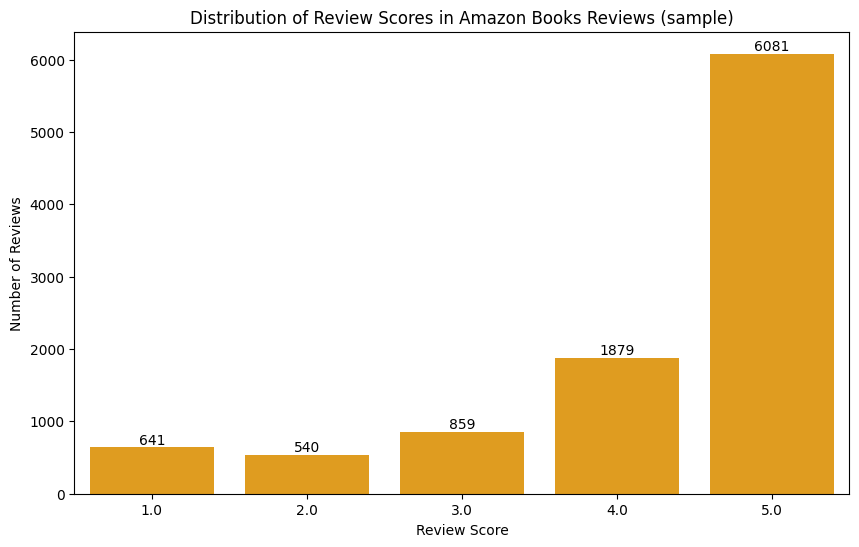

In [ ]:
#Visulization with bar chart
plt.figure(figsize=(10, 6))
sns.countplot(df_sample, x= "review/score", color = "orange")
plt.title("Distribution of Review Scores in Amazon Books Reviews (sample)")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

# Annotate bars with counts
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha="center", va="center",
                xytext=(0, 5),
                textcoords="offset points")

plt.show()

**Observation:**
The rating distribution shows a strong skew toward higher ratings (4-5 star) and fewer low ratings (1–2 stars) which indicates a positive bias. Hence, relying on raw ratings alone may inflate book rankings. This skew supports our hypothesis that normalization may produce fairer comparisons. Sentiment analysis may help to distinguish between generic and emotionally rich and informative 5-star reviews. Hence, this dataset is suitable for exploring whether sentiment provides additional discrimination power. Exploring review text & summary

### **Exploring review text & summary**

In [ ]:
#Length of the summary and text
df_sample['summary_length'] = df_sample['review/summary'].astype(str).apply(len)
df_sample['text_length'] = df_sample['review/text'].astype(str).apply(len)

#Describing the length
print("Display the first 5 reviews")
display(df_sample[['review/summary', 'summary_length', 'review/text', 'text_length']].head())
print("\n\nDescribe the reviews")
display(df_sample[['review/summary', 'summary_length', 'review/text', 'text_length']].describe())

Display the first 5 reviews


,review/summary,summary_length,review/text,text_length
2896109,Best edition of this classic.,29,I've always recommended this Yale edition of F...,2125
2381153,Great Book!!,12,This is required reading for my 16 yr old son....,100
1028690,Not just a book for consultant,30,"Plain-spoken, finished the book only has taken...",260
1945977,Outrageously Bad,16,Wow... this is one of the most ridiculous stor...,348
2812693,Cunning and determination,25,A crew has mutinied and threatens to hang thei...,1198




Describe the reviews


,summary_length,text_length
count,10000.000000,10000.000000
mean,28.087400,820.118700
std,15.712773,952.328605
min,1.000000,10.000000
25%,16.000000,260.000000
50%,25.000000,518.000000
75%,37.000000,1012.000000
max,123.000000,25405.000000


**Observation:** We observe a large variation in review length. There are some very short reviews and some extremely long reviews. This is important to take note of as short reviews may not contain enough information for meaningful sentiment analysis while long reviews may dominate sentiment scoring unless normalized. Hence, for for our analysis, we have to remove extremely short reviews and normalize sentiment scores by review length to examine correlation between review length and helpfulness votes

### **Data quality consideration:**
- In terms of completeness, the dataset compromises of a large number of book reviews across many titles, including both star ratings and written review text. This provides adequate coverage and depth to extract sentiment features, to then be compared with numerical ratings.

- The dataset supports straightforward analysis and interpretation as it consists of clearly defined attributes (overall rating, review text, helpfulness votes, and review data). These variables have straightforward semantics, making misinterpretation during analysis unlikely.


- Potential issues such as duplicate or spam reviews cannot be ruled out.

### **Conclusion:**
Despite the moderate concerns regarding rating imbalance and potential noise, the dataset closely matches our analytical requirements. We are however aware that skewed rating distributions and possible noise in review text may affect model performance and will address these during preprocessing and normalization.  

## DS2: Top 100 Bestselling Book Reviews on Amazon

**Description:** This dataset contains reviews from the top 100 bestselling books on Amazon. Although it provides relevant review text and ratings similar to Dataset 1, the scope of this dataset is limited as it only pertains to a small fraction of popular books.


In [ ]:
# Read in the csv file into a DataFrame
df_top100 = pd.read_csv('Top-100 Trending Books.csv')

#Display the first 5 rows of DS2
display(df_top100.head())

,Rank,book title,book price,rating,author,year of publication,genre,url
0,1,"Iron Flame (The Empyrean, 2)",18.42,4.1,Rebecca Yarros,2023,Fantasy Romance,amazon.com/Iron-Flame-Empyrean-Rebecca-Yarros/...
1,2,The Woman in Me,20.93,4.5,Britney Spears,2023,Memoir,amazon.com/Woman-Me-Britney-Spears/dp/16680090...
2,3,My Name Is Barbra,31.50,4.5,Barbra Streisand,2023,Autobiography,amazon.com/My-Name-Barbra-Streisand/dp/0525429...
3,4,"Friends, Lovers, and the Big Terrible Thing: A...",23.99,4.4,Matthew Perry,2023,Memoir,amazon.com/Friends-Lovers-Big-Terrible-Thing/d...
4,5,How to Catch a Turkey,5.65,4.8,Adam Wallace,2018,"Childrens, Fiction",amazon.com/How-Catch-Turkey-Adam-Wallace/dp/14...


In [ ]:
#Display the number of rows and columns, column names and non-null counts
print("Describe the dataset\n")
print(df_top100.info())

Describe the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Rank                 100 non-null    int64  
 1   book title           100 non-null    object 
 2   book price           100 non-null    float64
 3   rating               97 non-null     float64
 4   author               100 non-null    object 
 5   year of publication  100 non-null    int64  
 6   genre                100 non-null    object 
 7   url                  100 non-null    object 
dtypes: float64(2), int64(2), object(4)
memory usage: 6.4+ KB
None


Text(0, 0.5, 'Number of Books')

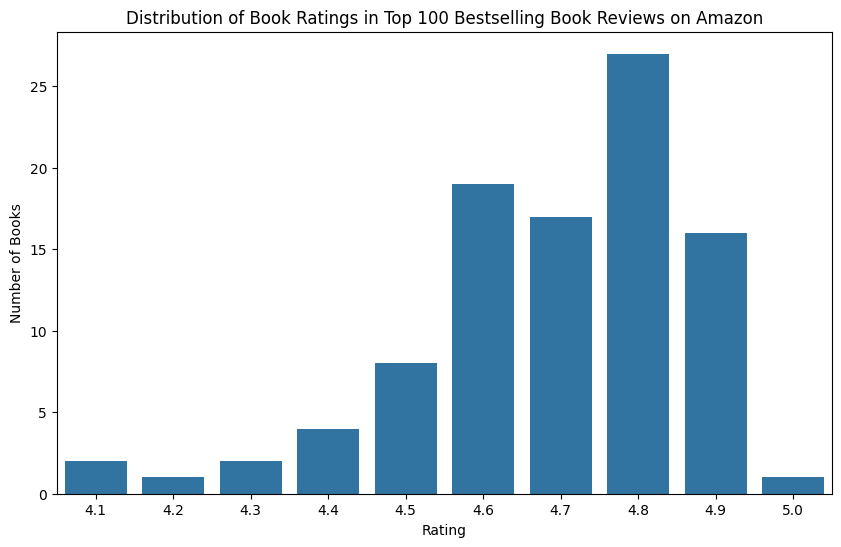

In [ ]:
#Visualize the distribution of the star ratings of the top 100 books, using a histrogram
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=df_top100.dropna(subset=['rating']))
plt.title('Distribution of Book Ratings in Top 100 Bestselling Book Reviews on Amazon')
plt.xlabel('Rating')
plt.ylabel('Number of Books')

**Observation and Data quality:**
This dataset comprises reviews from the top 100 bestselling books on Amazon. This means that the scope of this dataset is limited to a small fraction of popular books, even though it provides relevant review text and ratings. Hence, it lacks adequate range and variety across many unique titles and genres, which will have a negative impact when performing large-scale sentiment analysis.


**Conclusions:** We did not select this bestselling book reviews dataset mainly due to its small size and limited coverage. It did not satisfy our requirements for a more comprehensive analysis and would only result in biased and unreliable results.


## DS3: Amazon Kindle Book Review for Sentiment Analysis

**Description:** A large dataset of Kindle book reviews containing review text, ratings, and metadata, where sentiments are typically derived from ratings (e.g., positive/negative). It is commonly used to train and evaluate NLP models for text classification and opinion mining.

In [ ]:
#Display the first 5 rows of DS3
df_kindle = pd.read_csv('all_kindle_review .csv')
print("First 5 rows")
display(df_kindle.head())

First 5 rows


,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [ ]:
#Profiling DS3, understanding the columns value, data type and missing values
display(df_kindle.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    12000 non-null  int64 
 1   Unnamed: 0      12000 non-null  int64 
 2   asin            12000 non-null  object
 3   helpful         12000 non-null  object
 4   rating          12000 non-null  int64 
 5   reviewText      12000 non-null  object
 6   reviewTime      12000 non-null  object
 7   reviewerID      12000 non-null  object
 8   reviewerName    11962 non-null  object
 9   summary         11998 non-null  object
 10  unixReviewTime  12000 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 1.0+ MB


None

### **Exploring numerical rating**

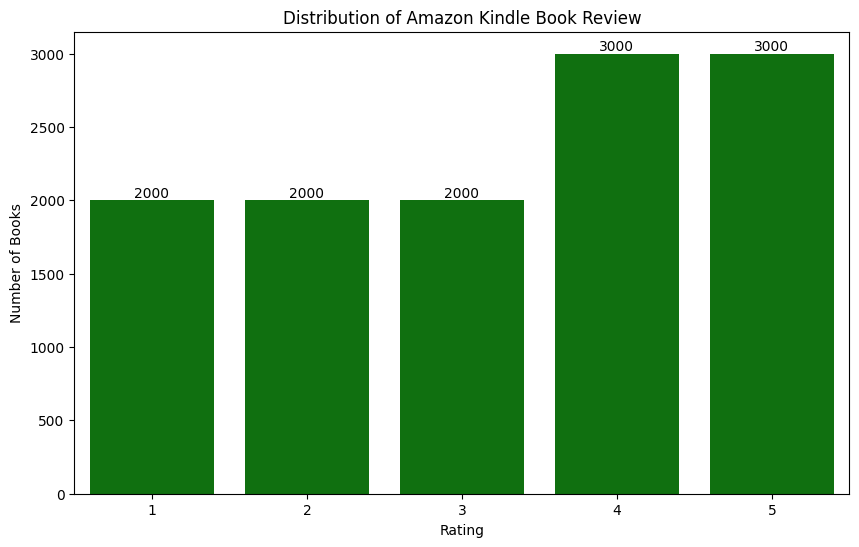

In [ ]:
#Visualization of the review's distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=df_kindle.dropna(subset=['rating']), color ="green")
plt.title('Distribution of Amazon Kindle Book Review')
plt.xlabel('Rating')
plt.ylabel('Number of Books')

# Annotate bars with counts
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha="center", va="center",
                xytext=(0, 5),
                textcoords="offset points")

plt.show()

### **Exploring review text & summary**

In [ ]:
df_kindle['reviewText_length'] = df_kindle['reviewText'].astype(str).str.len()
df_kindle['summary_length'] = df_kindle['summary'].astype(str).str.len()

#Describing the length
print("Display the first 5 reviews")
display(df_kindle[['reviewText', 'reviewText_length', 'summary', 'summary_length']].head())
print("\n\nDescribe the reviews")
display(df_kindle[['reviewText', 'reviewText_length', 'summary', 'summary_length']].describe())

Display the first 5 reviews


,reviewText,reviewText_length,summary,summary_length
0,"Jace Rankin may be short, but he's nothing to ...",2921,Entertaining But Average,24
1,Great short read. I didn't want to put it dow...,371,Terrific menage scenes!,23
2,I'll start by saying this is the first of four...,416,Snapdragon Alley,16
3,Aggie is Angela Lansbury who carries pocketboo...,336,very light murder cozy,22
4,I did not expect this type of book to be in li...,90,Book,4




Describe the reviews


,reviewText_length,summary_length
count,12000.000000,12000.000000
mean,601.562750,22.225833
std,710.158377,14.958910
min,7.000000,1.000000
25%,170.750000,12.000000
50%,332.000000,18.000000
75%,737.000000,29.000000
max,12246.000000,128.000000


**Observation and Data quality:**

The dataset seems to be pre-labelled for this analysis task, but unfortunately, a closer look at the data, we suspect that it may contain synthetic or pre-processed data.

While the labelling makes it much more convenient for our model training, it does not align with our goal of deriving sentiment and emotion features separately. This dataset would hence, limit our flexibility. Moreover, compatible identifiers are not present in this dataset which would have been used to merge with the book metadata from Dataset 4. This would make integration more complicated.


**Conclusions:**

This dataset was rejected due to worries about authenticity and incompatibility with our data pipeline.


## DS4: Amazon Books - books_data.csv



**Description:**  This Kaggle dataset, a metadata dataset on Amazon books, provides descriptive information on individual books, which offer relevant context for analysing and consolidating customer reviews at the book level. More specifically, it includes attributes such as book title, author, genre and publication details which are at an appropriate level of granularity to be linked with the review data from Dataset 1.  These identifiers link multiple reviews to the corresponding book, enabling the meaningful aggregation of sentiment and emotional features by title.  The following code imports the data to display the first few rows, thereby giving an overview of the stored book attributes.

In [ ]:
#Importing the dataset
#File too large, so we cannot import directly. Instead, we import DS1 from Kaggle
path = kagglehub.dataset_download("mohamedbakhet/amazon-books-reviews")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-books-reviews' dataset.
Path to dataset files: /kaggle/input/amazon-books-reviews


In [ ]:
full_csv_path = os.path.join(path, "books_data.csv") #Choose the correct csv file
csv_filename = "books_data.csv"

#Displaying the first 5 rows of DS4 with exception handling
try:
    df_books = pd.read_csv(full_csv_path)
    print(f"Successfully loaded '{csv_filename}'.")
    display(df_books.head())
except FileNotFoundError:
    print(f"Error: The file '{csv_filename}' was not found in '{path}'.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully loaded 'books_data.csv'.


,Title,description,authors,image,previewLink,publisher,publishedDate,infoLink,categories,ratingsCount
0,Its Only Art If Its Well Hung!,NaN,['Julie Strain'],http://books.google.com/books/content?id=DykPA...,http://books.google.nl/books?id=DykPAAAACAAJ&d...,NaN,1996,http://books.google.nl/books?id=DykPAAAACAAJ&d...,['Comics & Graphic Novels'],NaN
1,Dr. Seuss: American Icon,Philip Nel takes a fascinating look into the k...,['Philip Nel'],http://books.google.com/books/content?id=IjvHQ...,http://books.google.nl/books?id=IjvHQsCn_pgC&p...,A&C Black,2005-01-01,http://books.google.nl/books?id=IjvHQsCn_pgC&d...,['Biography & Autobiography'],NaN
2,Wonderful Worship in Smaller Churches,This resource includes twelve principles in un...,['David R. Ray'],http://books.google.com/books/content?id=2tsDA...,http://books.google.nl/books?id=2tsDAAAACAAJ&d...,NaN,2000,http://books.google.nl/books?id=2tsDAAAACAAJ&d...,['Religion'],NaN
3,Whispers of the Wicked Saints,Julia Thomas finds her life spinning out of co...,['Veronica Haddon'],http://books.google.com/books/content?id=aRSIg...,http://books.google.nl/books?id=aRSIgJlq6JwC&d...,iUniverse,2005-02,http://books.google.nl/books?id=aRSIgJlq6JwC&d...,['Fiction'],NaN
4,"Nation Dance: Religion, Identity and Cultural ...",NaN,['Edward Long'],NaN,http://books.google.nl/books?id=399SPgAACAAJ&d...,NaN,2003-03-01,http://books.google.nl/books?id=399SPgAACAAJ&d...,NaN,NaN


In [ ]:
#Display the number of rows and columns, column names and non-null counts
display(df_books.info())

#Number of unique books
print(f"\n\nNumber of unique users in df_data: {df_books["Title"].nunique()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212404 entries, 0 to 212403
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Title          212403 non-null  object 
 1   description    143962 non-null  object 
 2   authors        180991 non-null  object 
 3   image          160329 non-null  object 
 4   previewLink    188568 non-null  object 
 5   publisher      136518 non-null  object 
 6   publishedDate  187099 non-null  object 
 7   infoLink       188568 non-null  object 
 8   categories     171205 non-null  object 
 9   ratingsCount   49752 non-null   float64
dtypes: float64(1), object(9)
memory usage: 16.2+ MB


None



Number of unique users in df_data: 212403


**Observation:**
- From examining the initial rows and summary statistics, it is shown that each row corresponds to a particular book with descriptive metadata such as title, author, categories/genre, ratings count, etc. The presence of a unique identifier (e.g., ASIN or book ID) allows the dataset to be linked with Dataset 1 at the book level.

- The granularity of the dataset is appropriate for our analysis, as it is organised by book, so multiple reviews can be combined into a single overall sentiment score for each title. Details like genre and author also allow for further exploration of how sentiment may vary across different types of books.



- Some attributes (categories, authors, etc.) may appear in list-like or string formats and thus have to undergo pre-processing before  any further analysis. During data preparation, missing values in certain fields also need to be accounted for.


### **Data quality considerations:**
- In terms of completeness, the dataset provides sufficient descriptive information about books to support aggregation and contextual analysis. Key identifiers required for linking with the review dataset are present, enabling integration across datasets.
- The interpretability of the dataset is generally high, as attributes such as title, author, and genre have clear semantics and are directly meaningful for recommendation purposes. This reduces ambiguity during feature engineering and aggregation.
- However, some attributes may contain missing or inconsistently formatted values, particularly in genre or publication fields. In addition, differences in naming conventions or duplicate book titles may complicate the merging process with the review dataset.


### **Conclusion:**
Despite these minor data quality concerns, the dataset closely matches our analytical requirements. We are aware that careful preprocessing and cleaning will be necessary to ensure accurate merging and avoid aggregation errors, but overall the dataset is well-suited for supporting book-level recommendation modeling.

## DS5: Book Recommendation Dataset - Books.csv

**Description:** The Book Recommendation Dataset is a huge dataset containing book metadata, user information, and user ratings, designed for building recommendation systems. It includes millions of ratings linked to books (via ISBN) and anonymized users.

In [ ]:
#Load DS5 into a Dataframe
df_rec = pd.read_csv('Books.csv')
display(df_rec.head())

/tmp/ipykernel_436/2608008518.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rec = pd.read_csv('Books.csv')


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [ ]:
#Number of unique books
print(f"Number of unique users in df_rec: {df_rec["Book-Title"].nunique()}\n\n")

#Display the number of rows and columns, column names and non-null counts
display(df_rec.info())

Number of unique users in df_rec: 242135


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


None

**Observation and Data quality:** This dataset comprises book-related information which can be used for our recommendation system. Unfortunately, when we performed exploratory analysis, we realised that the data is heavily clustered and unevenly distributed. This would result in biased and unreliable results which would ultimately have an impact on making meaningful comparisons across various books.

Moreover, as this dataset is primarily a metadataset, not a review dataset and hence, lacks necessary textual data. So, it will not align well with our aim of focussing on sentiment and emotion analysis of review text.


**Conclusions:** This dataset was not chosen primarily because of its skewed structure and minimal applicability to our objectives.


## DS6: GoEmotions - goemotions_1.csv

**Description:** This GoEmotions dataset, developed by Google, contains annotated text samples labelled with 27 distinct emotions plus a neutral category. This helps to provide fine-grained emotion labels which capture nuanced readers' reactions while analysing emotional content in written reviews. These text samples accompanied by emotion labels provide a suitable foundation to train or apply models to detect emotions from the Amazon review data from Dataset 1. Using this dataset will allow us to get a deeper understanding of reader sentiment beyond simple star rating. The following code imports the data into a DataFrame and displays the first few rows, thereby providing an overview of the stored annotations and text samples.

In [ ]:
#Loading DS6 and displaying the first 5 rows
df_goemo= pd.read_csv('goemotions_1.csv')
print("First 5 rows")
display(df_goemo.head())

First 5 rows


,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1


**Observation**:
The first few rows of the dataset shows that each row has a short text sample, being linked to one or more emotion labels. The emotion label categories encompass a wide range, including optimism, sadness, anger and even neutral. This allows for the sentiments extracted from the textual review data to be much more detailed.

This dataset is based on separate text samples, making it ideal for training machine learning models that classify emotions.

However, the text samples in this data set are generally short and sound conversational as opposed to the longer and more detailed review texts present in Dataset 1. Hence, this disparity should be taken into account when applying the model as it may lead to unreliable results.

Overall, the dataset serves as a firm basis for extracting emotional features, which can be applied to Amazon review data to enhance sentiment analysis and recommendation quality.

/tmp/ipykernel_804/4032883111.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='viridis')


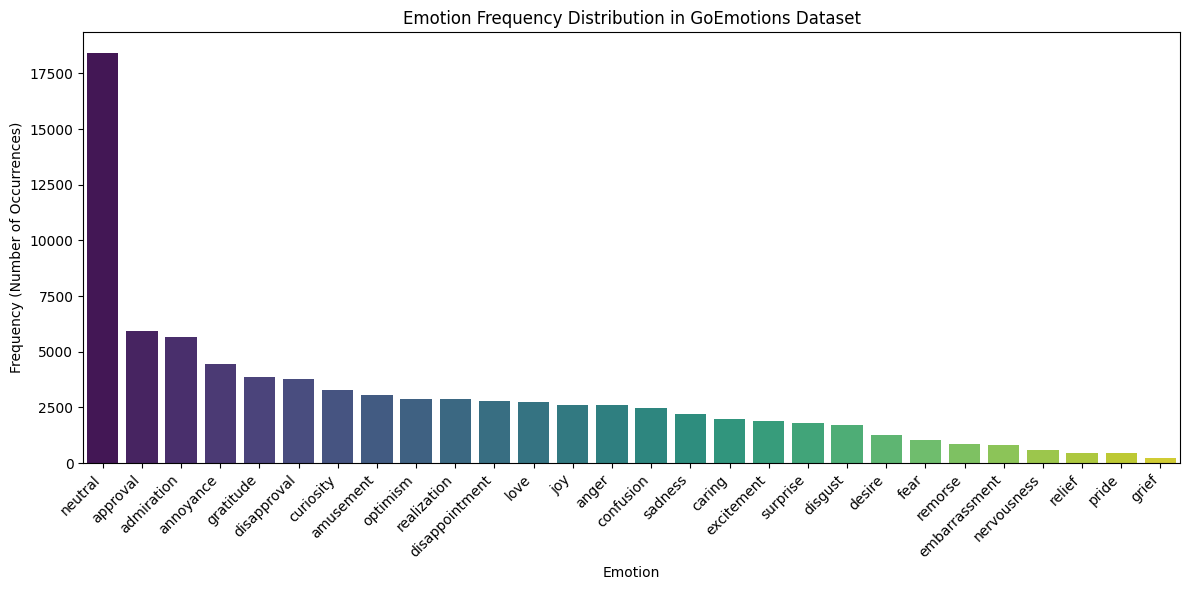

In [ ]:
#List of common emotion labels in GoEmotions dataset
#These are typically binary (0/1) columns indicating presence of emotion
emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
    'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
    'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
    'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
    'relief', 'remorse', 'sadness', 'surprise', 'neutral'
]

emotion_counts = df_goemo[emotion_cols].sum().sort_values(ascending=False)

#Visualize the frequency distribution in DS6
plt.figure(figsize=(12, 6))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette='viridis')
plt.title('Emotion Frequency Distribution in GoEmotions Dataset')
plt.xlabel('Emotion')
plt.ylabel('Frequency (Number of Occurrences)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Data quality considerations:**
- In terms of completeness, the dataset compromises of a substantial collection of annotated text samples with specifically defined emotion labels. The dataset provides an extensive scope to capture diverse emotional reactions within the textual data, primarily due to the presence of 27 distinct emotion categories as well as a neutral class.

- The dataset supports straightforward analysis and interpretation as each label corresponds to a distinct emotional state. This clear structure allows for straightforward mapping between textual expressions and their representative emotional categories during analysis.

- However, the multi-label nature of the annotations pose certain issues, as a single text sample may correspond to multiple emotions. This can complicate model training and may need objective decisions to be made on whether to prioritize labels or to take on a multi-label classification approach.

### **Conclusion:**
This GoEmotions dataset is well suited for our project’s analysis. It offers detailed and nuanced emotion labels which facilitate a deeper interpretation sentiment beyond simple positive or negative classification. This dataset enables the integration of emotional features into our recommendation system, yielding more relevant and insightful book rankings.




# **Data Preparation (Process)**

## Overview

The core of this project moves beyond the trap of just relying on star ratings where numbers fail to capture a reader’s true experience. To solve this, our pipeline processes three distinct data streams to create a multidimensional view of book quality. DS1 (Amazon Reviews) acts as the main engine where we make sure that the ratings undergo cleaning and structuring.

 This phase includes handling missing value, selecting key attributes and schema validation before enriching them with the Helpfulness Ratio. Hence, the resulting sentiment that is to be extracted will originate from validated and actionable user input. where ratings are cleaned, structured, and enhanced with a helpfulness ratio to ensure reliable sentiment extraction.

In parallel, DS4 (Book Metadata) provides context such as title, author, and genre. After validation, this data is joined with reviews through an “enriching join,” allowing sentiment to be analysed at the book level rather than as isolated comments.

Finally, DS6 (GoEmotions) adds emotional depth by identifying nuanced feelings like optimism or disappointment. By integrating these emotional profiles with the processed data, the final database ranks books based not just on ratings, but on helpfulness, context, and genuine human emotion.

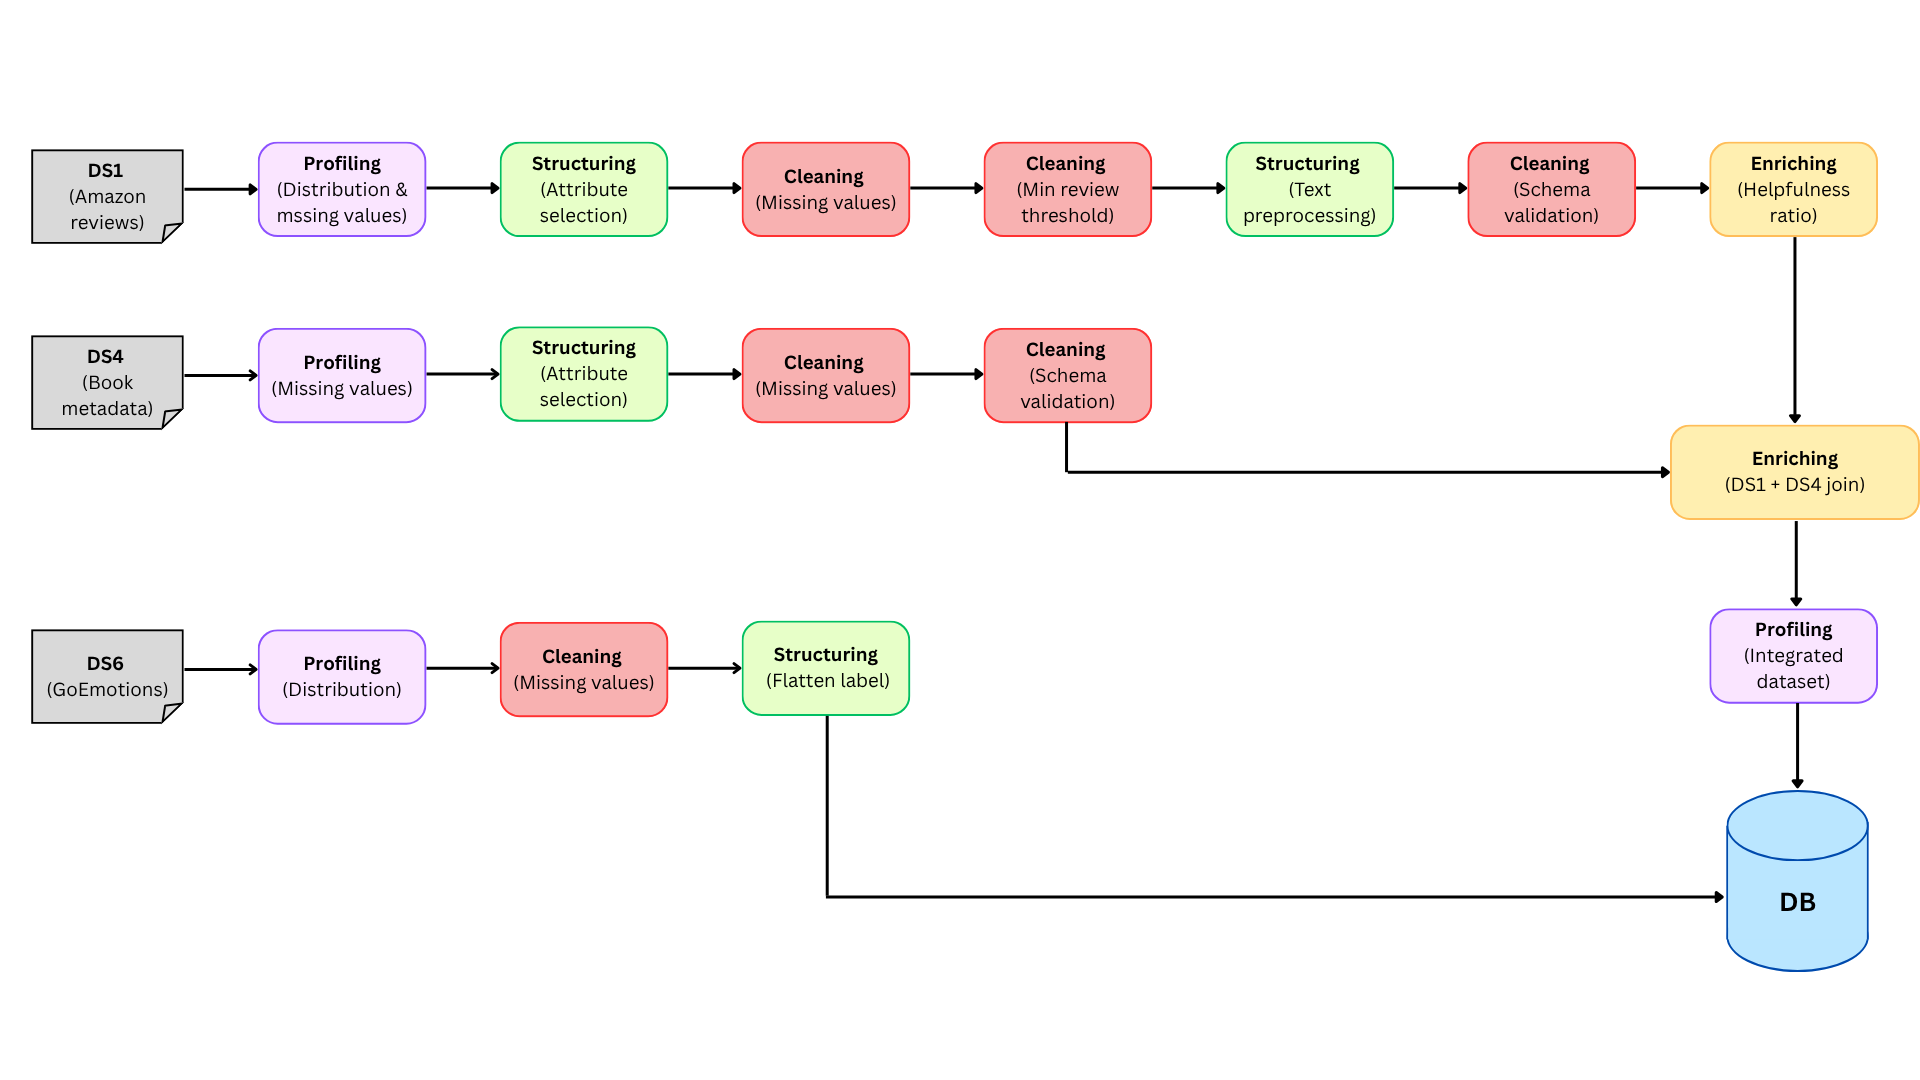

## DS1, DS4, DS6: Profiling - Distribution & Missing Values
Understand the profile of chosen datasets

All profiling steps of 3 datasets are already implemented in the Prepare stage. We have explained clearly the goals, methods and intepretations for each dataset.

## DS1: Data Structuring - Attribute Selection
Filter irrelevant columns and rows



Here, we standardize the column names in the sampled review dataset (df_sample) to make it clearer for us to comprehend and to subsequent processing more efficient. Renaming columns such as review/score to rating and review/text to text also enables a cleaner and more efficient analysis.

Additionally, we remove non-essential identifiers (User_id, profileName,review/time). These fields do provide context and additional information but they are not primary features needed for the sentiment and emotion-based analysis. Removing them reduces memory overhead and focuses the dataset on only the required content


In [ ]:
# Rename columns for consistency and usability
df_sample = df_sample.rename(columns={
    'review/score': 'rating',
    'review/text': 'text',
    'review/summary': 'summary',
    'review/helpfulness': 'helpfulness'
})

# Define and drop irrelevant identifier columns
columns_to_drop = ['User_id', 'profileName', 'review/time']
df_sample = df_sample.drop(columns=[col for col in columns_to_drop if col in df_sample.columns])

# Display the first few rows to verify the updated structure
print('Updated df_sample structure:')
display(df_sample.head())

Updated df_sample structure:


,Id,Title,Price,helpfulness,rating,summary,text
2896109,B000PYIUAI,The Autobiography of Benjamin Franklin,NaN,3/3,5.0,Best edition of this classic.,I've always recommended this Yale edition of F...
2381153,B000PEHLVC,The scarlet letter: a romance,NaN,0/1,5.0,Great Book!!,This is required reading for my 16 yr old son....
1028690,0070534489,The McKinsey Way,17.65,0/0,4.0,Not just a book for consultant,"Plain-spoken, finished the book only has taken..."
1945977,0671551698,Dead Man's Walk (Lonesome Dove),NaN,3/7,1.0,Outrageously Bad,Wow... this is one of the most ridiculous stor...
2812693,0523421095,Lord Hornblower (Hornblower Saga),NaN,2/3,4.0,Cunning and determination,A crew has mutinied and threatens to hang thei...


## DS1: Data Cleaning - Missing Values
Detect and impute null review text and ratings

To ensure the reliability of our sentiment analysis and subsequent statistical modeling, it is a must to handle missing values. More specifically, we focus on the text and rating columns, as these are extremely important for extracting emotional insights and comparing them with the assigned numerical scores. To ensure that our analysis relies on complete and reliable data, we would also remove rows with null entries in these fields. This would also help in avoiding errors during natural language processing and preserving the consistency of our recommendation system.

In [ ]:
# Check for missing values in essential columns
missing_text = df_sample['text'].isnull().sum()
missing_rating = df_sample['rating'].isnull().sum()

print(f"Missing values in 'text': {missing_text}")
print(f"Missing values in 'rating': {missing_rating}")

# Drop rows where 'text' or 'rating' are null
df_sample = df_sample.dropna(subset=['text', 'rating'])

# Convert 'rating' to integer for consistent numerical processing
df_sample['rating'] = df_sample['rating'].astype(int)

# Verify the cleaning process
print(f"\nNew DataFrame shape: {df_sample.shape}")
print("First 5 rows of cleaned 'text' and 'rating' columns:")
display(df_sample[['text', 'rating']].head())

Missing values in 'text': 0
Missing values in 'rating': 0

New DataFrame shape: (10000, 7)
First 5 rows of cleaned 'text' and 'rating' columns:


,text,rating
2896109,I've always recommended this Yale edition of F...,5
2381153,This is required reading for my 16 yr old son....,5
1028690,"Plain-spoken, finished the book only has taken...",4
1945977,Wow... this is one of the most ridiculous stor...,1
2812693,A crew has mutinied and threatens to hang thei...,4


## DS1: Data Cleaning - Applying Minimum Threshold
Remove books below minimum review count


We filter df_sample to include only books with 3 or more reviews



In [ ]:
#Calculate the number of reviews
book_review_counts = df_sample.groupby('Title').size().reset_index(name='review_count')

#Identify titles with at least 3 reviews
min_3_titles = book_review_counts[book_review_counts['review_count'] >= 3]['Title']

#Use .copy() to avoid SettingWithCopyWarning during later attribute assignments
df_filtered_min3 = df_sample[df_sample['Title'].isin(min_3_titles)].copy()

#Verify the result
print(f'Original rows: {len(df_sample)}')
print(f'Rows after filtering (min 3 reviews): {len(df_filtered_min3)}')
print(f'Number of unique books remaining: {df_filtered_min3["Title"].nunique()}')

display(df_filtered_min3.head())

Original rows: 9996
Rows after filtering (min 3 reviews): 2926
Number of unique books remaining: 549


,Id,Title,Price,helpfulness,rating,summary,text,review_length,clean_review,helpful_ratio
2896109,B000PYIUAI,The Autobiography of Benjamin Franklin,NaN,3/3,5,Best edition of this classic.,I've always recommended this Yale edition of F...,2125,ive always recommended this yale edition of fr...,1.0
2065430,0451521196,Wuthering Heights (Signet classics),NaN,1/1,5,Fantastic Read,I absolutely love this book! Anyone who reads ...,169,i absolutely love this book anyone who reads c...,1.0
2192553,B000PMCF1A,The Catcher in the Rye [Audiobook] [Cd] [Unabr...,NaN,0/0,5,Still a great read!,This novel has truly withstood the test of tim...,263,this novel has truly withstood the test of tim...,0.0
1018464,B0006D1ZKU,The grapes of wrath,NaN,1/1,5,"Great, thought -provoking book","Before I read this book, I was told that it is...",835,before i read this book i was told that it is ...,1.0
414422,0816156921,Dracula (G. K. Hall (Large Print)),NaN,0/0,5,Terrifying!!,"For some stupid reason, I always read Dracula ...",323,for some stupid reason i always read dracula i...,0.0


## DS1: Data Structuring - Text Preprocessing for DS1
Tokenize, lowercase, remove stopwords and punctuation in text reviews


Tokenize, lowercase, remove stopwords and punctuation in text reviews

In this step, we prepare the raw review text for sentiment analysis through two key processes:

1. **Text Normalization:** We run a cleaning function on the text column to create a clean_review feature. This would convert all text to lowercase, strip non-alphabetic characters and remove URLs. This ensures that the sentiment model does not have to regard noise.

2. **Short Review Filtering:** Reviews with fewer than 30 characters are removed using the review_length column. These extremely short entries (e.g., "Ok", "Good!") often lack sufficient context or emotional depth for reliable sentiment and emotion extraction.

At the end, the dataset will consist of normalized, substantive text samples ready for natural language processing.

In [ ]:
#Create review length column
df_sample["review_length"] = df_sample["text"].str.len()

df_sample[["text", "review_length"]].head()


,text,review_length
2896109,I've always recommended this Yale edition of F...,2125
2381153,This is required reading for my 16 yr old son....,100
1028690,"Plain-spoken, finished the book only has taken...",260
1945977,Wow... this is one of the most ridiculous stor...,348
2812693,A crew has mutinied and threatens to hang thei...,1198


In [ ]:
def clean_text(text):
    text = text.lower() #Convert to lowercase
    text = re.sub(r'http\S+', '', text) #Remove URLs
    text = re.sub(r'[^a-z\s]', '', text) #Strip away all non-alphabetic characters (keep only letters and spaces
    text = ' '.join(text.split()) #Remove extra whitespace
    return text.strip()

#Apply the cleaning function to create 'clean_review'
df_sample['clean_review'] = df_sample['text'].apply(clean_text)

#Filter df_sample to retain only reviews longer than 30 characters
#Using the 'review_length' column created in the previous step
df_sample = df_sample[df_sample['review_length'] > 30]
#Extremely short reviews are removed because they often lack meaningful linguistic content needed for emotion detection.

#Display the results
print(f'New DataFrame shape after filtering: {df_sample.shape}')
print('\nFirst 5 cleaned reviews:')
display(df_sample[['text', 'clean_review', 'review_length']].head())

New DataFrame shape after filtering: (9996, 9)

First 5 cleaned reviews:


,text,clean_review,review_length
2896109,I've always recommended this Yale edition of F...,ive always recommended this yale edition of fr...,2125
2381153,This is required reading for my 16 yr old son....,this is required reading for my yr old sonbook...,100
1028690,"Plain-spoken, finished the book only has taken...",plainspoken finished the book only has taken m...,260
1945977,Wow... this is one of the most ridiculous stor...,wow this is one of the most ridiculous story i...,348
2812693,A crew has mutinied and threatens to hang thei...,a crew has mutinied and threatens to hang thei...,1198


**Observation:**
- The 'text_length' column has a mean of about 480 characters, ranging from 0 to 4801 characters. This also indicates considerable variability in review detail, with some reviews being very brief and others quite extensive.


## DS1: Data Enriching - Helpfulness Ratio
Derive helpfulness ratio from votes columns



In this step, we derive two numerical features to enhance our analysis of review utility:

1. **Helpful Ratio**: The original helpfulness column is stored as a string (e.g., '5/10'). By parsing this into a numerical helpful_ratio (0.5), we can mathematically correlate review utility with star ratings and sentiment scores.

2. **Review Length**: We calculate the character length of each review. This will help us answer the question that if more wordy and detailed reviews tend to be seen as more helpful or if they carry varying sentiment value compared to shorter ones.

These features are essential for the descriptive and predictive parts of our recommendation framework.

In [ ]:
def calculate_helpful_ratio(help_str):
    try:
        parts = str(help_str).split('/')
        if len(parts) == 2:
            numerator = int(parts[0])
            denominator = int(parts[1])
            return numerator / denominator if denominator > 0 else 0.0
        return 0.0
    except (ValueError, ZeroDivisionError):
        return 0.0

# Calculate helpful_ratio
df_sample['helpful_ratio'] = df_sample['helpfulness'].apply(calculate_helpful_ratio)

# Calculate review_length
df_sample['review_length'] = df_sample['text'].str.len()

print('Features engineered successfully.')
display(df_sample[['helpfulness', 'helpful_ratio', 'text', 'review_length']].head())

Features engineered successfully.


,helpfulness,helpful_ratio,text,review_length
2896109,3/3,1.000000,I've always recommended this Yale edition of F...,2125
2381153,0/1,0.000000,This is required reading for my 16 yr old son....,100
1028690,0/0,0.000000,"Plain-spoken, finished the book only has taken...",260
1945977,3/7,0.428571,Wow... this is one of the most ridiculous stor...,348
2812693,2/3,0.666667,A crew has mutinied and threatens to hang thei...,1198


## DS4: Data Cleaning - Missing Values and Schema Errors
Detect nulls, fix types, standardize fields



An important step would be to clean the metadata dataset (df_books). This will help to ensure that the merge the the dataset 1 is consistent. Furthermore, standardizing the 'Title' column by converting the data input to lowercase and removing any unnecessary whitespace will help to remove inconsistencies.Not doing so would prevent successful matching matching.

It is also important to address the missing values in the 'authors' and categories' columns by assigning them the label 'unknown'. This helps to preserve retain key data while serving as clear categorical indicators. Deleting duplicates and entries with null titles makes sure that every record in the final consolidated dataset is distinct and correctly identifies the book it talks about.


In [ ]:
# Remove duplicate books based on title
df_books = df_books.drop_duplicates(subset=["Title"])

print("Rows after removing duplicates:", df_books.shape)

# Duplicate entries are removed to ensure that each book title appears only once when linking metadata with review data.

Rows after removing duplicates: (209456, 11)


In [ ]:
# # Remove rows where title is missing
df_books = df_books.dropna(subset=["Title"])

print("Rows after removing missing titles:", df_books.shape)

# Records with missing book titles are removed because the title is required to link the metadata dataset with the review dataset.

Rows after removing missing titles: (212403, 10)


In [ ]:
# Clean the book title column
df_books["Title"] = df_books["Title"].str.lower().str.strip()

df_books["Title"].head()

# Titles are standardized by converting them to lowercase and removing leading and trailing whitespace to improve matching accuracy during dataset merging.

,Title
0,its only art if its well hung!
1,dr. seuss: american icon
2,wonderful worship in smaller churches
3,whispers of the wicked saints
4,"nation dance: religion, identity and cultural ..."


In [ ]:
# Replace missing author values
df_books["authors"] = df_books["authors"].fillna("unknown")

# Replace missing categories
df_books["categories"] = df_books["categories"].fillna("unknown")

df_books[["Title", "authors", "categories"]].head()

# Missing author and category values are replaced with “unknown” to preserve records while maintaining consistent metadata fields.

,Title,authors,categories
0,its only art if its well hung!,['Julie Strain'],['Comics & Graphic Novels']
1,dr. seuss: american icon,['Philip Nel'],['Biography & Autobiography']
2,wonderful worship in smaller churches,['David R. Ray'],['Religion']
3,whispers of the wicked saints,['Veronica Haddon'],['Fiction']
4,"nation dance: religion, identity and cultural ...",['Edward Long'],unknown


## DS1 + DS4 (Integrated Dataset): Data Enriching
Inner join on book title to produce integrated dataset

 Interrecord enriching via inner join. We link DS1 review records with DS4 book metadata on book title, combining two complementary schemas into one dataset.

 DS1 contains review-level signals (star rating, review text, helpfulness) but lacks book-level metadata (genre, author, publisher). DS4 provides metadata but no review data. Joining on book title enriches each review record with its corresponding book attributes, enabling cross-dataset analysis of how book characteristics relate to review sentiment.

In [ ]:
def robust_normalize(text):
    if not isinstance(text, str):
        return ""
    # Lowercase, remove non-alphanumeric, and strip whitespace
    text = text.lower()
    text = re.sub(r'[^a-z0-9]', '', text)
    return text.strip()

# Create normalized title columns for merging
df_filtered_min3['norm_title'] = df_filtered_min3['Title'].apply(robust_normalize)
df_books['norm_title'] = df_books['Title'].apply(robust_normalize)

# Deduplicate metadata to avoid many-to-many join issues (inflating row counts)
df_books_unique = df_books.drop_duplicates(subset=['norm_title'])

# Perform the left join to retain all reviews from the filtered sample
merged_df_robust = pd.merge(
    df_filtered_min3,
    df_books_unique,
    on='norm_title',
    how='left',
    suffixes=('_review', '_meta')
)

# Diagnostic Summary
print(f"Original reviews in filtered sample: {len(df_filtered_min3)}")
print(f"Rows in merged dataset: {len(merged_df_robust)}")

match_count = merged_df_robust['Title_meta'].notnull().sum()
print(f"Reviews matched with metadata: {match_count} ({(match_count/len(df_filtered_min3))*100:.2f}%)")

Original reviews in filtered sample: 2926
Rows in merged dataset: 2926
Reviews matched with metadata: 2926 (100.00%)


In [ ]:
columns_to_remove = [
    'Price', 'image', 'previewLink', 'publishedDate', #not needed in this recommendation system
    'helpfulness', #replaced by helpful_ratio
    'text', #replaced by clean_review
    'Title_meta', 'norm_title', #replaced by title_review
    'ratingsCount' #already met the minimum threshold
]

# Drop the specified columns if they exist in the DataFrame
merged_df_robust = merged_df_robust.drop(columns=[col for col in columns_to_remove if col in merged_df_robust.columns])

# Rename the 'rating' column to 'star_rating'
merged_df_robust = merged_df_robust.rename(columns={'rating': 'star_rating'})

print("DataFrame after removing columns and renaming 'rating':")
display(merged_df_robust.head())

# Save the final consolidated dataset
merged_df_robust.to_csv('Integrated_dataset.csv', index=False)
print('\nConsolidated dataset saved to Integrated_dataset.csv.')

DataFrame after removing columns and renaming 'rating':


,Id,Title_review,star_rating,summary,review_length,clean_review,helpful_ratio,description,authors,publisher,infoLink,categories
0,B000PYIUAI,The Autobiography of Benjamin Franklin,5,Best edition of this classic.,2125,ive always recommended this yale edition of fr...,1.0,"The Autobiography of Benjamin Franklin, which ...",['Benjamin Franklin'],Createspace Independent Publishing Platform,http://books.google.nl/books?id=16actQEACAAJ&d...,unknown
1,0451521196,Wuthering Heights (Signet classics),5,Fantastic Read,169,i absolutely love this book anyone who reads c...,1.0,The passionate love of Catherine Earnshaw and ...,['Emily Brontë'],Signet,http://books.google.nl/books?id=es7stjCghFgC&d...,['Audiobooks']
2,B000PMCF1A,The Catcher in the Rye [Audiobook] [Cd] [Unabr...,5,Still a great read!,263,this novel has truly withstood the test of tim...,0.0,I’ll Get There. It Better Be Worth the Trip. i...,['John Donovan'],"North Star Editions, Inc.",https://play.google.com/store/books/details?id...,['Young Adult Fiction']
3,B0006D1ZKU,The grapes of wrath,5,"Great, thought -provoking book",835,before i read this book i was told that it is ...,1.0,1940 Pulitzer Prize winner. Moving story of a ...,['John Steinbeck'],Gardners Books,http://books.google.com/books?id=FAlBAQAAIAAJ&...,['Fiction']
4,0816156921,Dracula (G. K. Hall (Large Print)),5,Terrifying!!,323,for some stupid reason i always read dracula i...,0.0,Having deduced the double identity of Count Dr...,"['Bram Stoker', 'Grand Theatre Collection (Uni...",NaN,http://books.google.com/books?id=AlDNcQAACAAJ&...,['High interest-low vocabulary books']



Consolidated dataset saved to Integrated_dataset.csv.


**Observation:** The final dataset, containing 2,926 rows and 12 columns (including ratings, cleaned text, helpfulness ratios, authors, and categories). We also achieve a 100% match rate, meaning no loss information.

## Integrated Dataset: Data Profiling

Multi-column cardinality, distributions, functional dependencies

We do multi-column profiling, specifically checks cardinality, value distributions, and functional dependency violations (e.g. Title → authors) on the merged dataset.

In [ ]:
#Use integrated dataset to not load the whole thing again

df_integrated = pd.read_csv('Integrated_dataset.csv')
display(df_integrated.head())

,Id,Title_review,star_rating,summary,review_length,clean_review,helpful_ratio,description,authors,publisher,infoLink,categories
0,B000PYIUAI,The Autobiography of Benjamin Franklin,5,Best edition of this classic.,2125,ive always recommended this yale edition of fr...,1.0,"The Autobiography of Benjamin Franklin, which ...",['Benjamin Franklin'],Createspace Independent Publishing Platform,http://books.google.nl/books?id=16actQEACAAJ&d...,unknown
1,0451521196,Wuthering Heights (Signet classics),5,Fantastic Read,169,i absolutely love this book anyone who reads c...,1.0,The passionate love of Catherine Earnshaw and ...,['Emily Brontë'],Signet,http://books.google.nl/books?id=es7stjCghFgC&d...,['Audiobooks']
2,B000PMCF1A,The Catcher in the Rye [Audiobook] [Cd] [Unabr...,5,Still a great read!,263,this novel has truly withstood the test of tim...,0.0,I’ll Get There. It Better Be Worth the Trip. i...,['John Donovan'],"North Star Editions, Inc.",https://play.google.com/store/books/details?id...,['Young Adult Fiction']
3,B0006D1ZKU,The grapes of wrath,5,"Great, thought -provoking book",835,before i read this book i was told that it is ...,1.0,1940 Pulitzer Prize winner. Moving story of a ...,['John Steinbeck'],Gardners Books,http://books.google.com/books?id=FAlBAQAAIAAJ&...,['Fiction']
4,0816156921,Dracula (G. K. Hall (Large Print)),5,Terrifying!!,323,for some stupid reason i always read dracula i...,0.0,Having deduced the double identity of Count Dr...,"['Bram Stoker', 'Grand Theatre Collection (Uni...",NaN,http://books.google.com/books?id=AlDNcQAACAAJ&...,['High interest-low vocabulary books']


In [ ]:
display(df_integrated.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2926 entries, 0 to 2925
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2926 non-null   object 
 1   Title_review   2926 non-null   object 
 2   star_rating    2926 non-null   int64  
 3   summary        2926 non-null   object 
 4   review_length  2926 non-null   int64  
 5   clean_review   2926 non-null   object 
 6   helpful_ratio  2926 non-null   float64
 7   description    2412 non-null   object 
 8   authors        2926 non-null   object 
 9   publisher      2231 non-null   object 
 10  infoLink       2642 non-null   object 
 11  categories     2926 non-null   object 
dtypes: float64(1), int64(2), object(9)
memory usage: 274.4+ KB


None

**Observation:**
- 9/12 columns fully complete, with missing values are non-critical for the final analysis.
- No duplicates, no functional dependency violations.

## DS6: Data Cleaning - Missing Values
Detect and remove null values

Instance-level error detection and removal. Rows with an empty labels list are missing values at the instance level. They contain no usable target variable and cannot be used for training or evaluation.

To ensure data completeness. Retaining empty-label rows would cause downstream errors during label access and corrupt the training set with unlabeled ones.

In [ ]:
emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
    'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
    'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
    'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
    'relief', 'remorse', 'sadness', 'surprise', 'neutral'
]

#Cleaning — drop rows where no emotion labels are present
df_goemo = df_goemo[df_goemo[emotion_cols].sum(axis=1) > 0]
print(f"After removing empty labels: {len(df_goemo)} rows")

After removing empty labels: 68871 rows


## DS6: Data Structuring - Single-label format
Flatten multi-label to single label

Intrarecord structuring via attribute creation. GoEmotions is a multi-label dataset where each row carries a list of emotion labels. A new attribute label is extracted from the existing labels list by taking the first element, converting the variable from a complex structure (list) to a scalar integer suitable for single-label classification.

The classification model requires exactly one integer label per example. Retaining the list format would be incompatible with standard cross-entropy loss functions which expect a single class index per row.

In [ ]:
dataset = Dataset.from_pandas(df_goemo)

def flatten_labels(example):
    active_emotions = [emotion for emotion in emotion_cols if example[emotion] == 1]
    if active_emotions:
        example["label"] = active_emotions[0] #Assign the first active emotion as the single label (string)
    else:

        example["label"] = "neutral" #Assign 'neutral' if no specific emotion is active
    return example

dataset = dataset.map(flatten_labels)
unique_labels = sorted(list(set(dataset['label'])))
emotion_to_int = {label: i for i, label in enumerate(unique_labels)}
dataset = dataset.map(lambda x: {"label_int": emotion_to_int[x["label"]]})

print(f"Label flattening done. Sample label (string): {dataset[0]['label']}")
print(f"Sample label (integer): {dataset[0]['label_int']}")
print(f"Emotion to integer mapping: {emotion_to_int}")

Map:   0%|          | 0/68871 [00:00<?, ? examples/s]

Map:   0%|          | 0/68871 [00:00<?, ? examples/s]

Label flattening done. Sample label (string): sadness
Sample label (integer): 26
Emotion to integer mapping: {'admiration': 0, 'amusement': 1, 'anger': 2, 'annoyance': 3, 'approval': 4, 'caring': 5, 'confusion': 6, 'curiosity': 7, 'desire': 8, 'disappointment': 9, 'disapproval': 10, 'disgust': 11, 'embarrassment': 12, 'excitement': 13, 'fear': 14, 'gratitude': 15, 'grief': 16, 'joy': 17, 'love': 18, 'nervousness': 19, 'neutral': 20, 'optimism': 21, 'pride': 22, 'realization': 23, 'relief': 24, 'remorse': 25, 'sadness': 26, 'surprise': 27}


# **Data Analysis (Analyze)**

We apply the following methods:
- Visualization (Descriptive analysis)
- Relationship and dependency analysis (Diagnostic analysis)
- Hypothesis testing and validation (Diagnostic analysis)
- Recommendation System Design (Prescriptive Analysis)
- System Comparison & Evaluation (Predictive Analysis)

## Visualization

**Goal:** To understand the distribution and general characteristics of the Amazon book review dataset, including star ratings, review lengths, helpfulness ratios, and basic sentiment polarity, before any modelling is performed.

**Method Justification:** Visualization is used here because it provides an immediate, intuitive summary of data shape, skew, and outliers without requiring assumptions. VADER is used for basic sentiment polarity at this stage because it is a pre-built lexicon-based tool that requires no training, making it valid before the predictive stage. Histograms reveal distribution shapes, box plots expose outliers, and word clouds surface dominant language patterns.

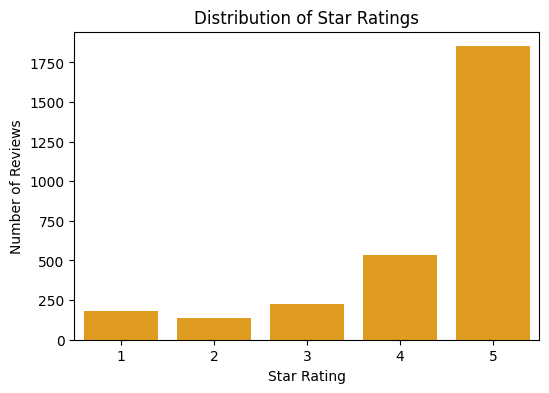

In [ ]:
#1. Distribution of Star Ratings
plt.figure(figsize=(6, 4))
sns.countplot(x='star_rating', data=df_integrated, color = "orange")
plt.title('Distribution of Star Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.show()

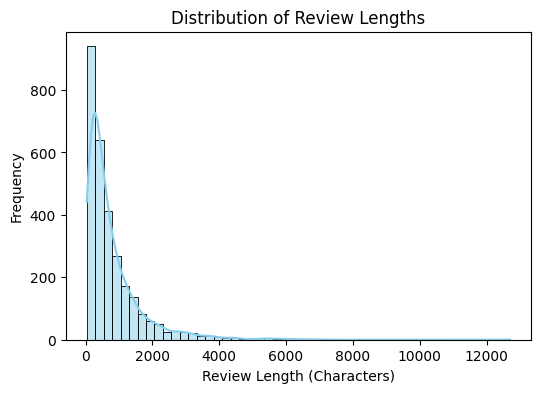

In [ ]:
#2. Distribution of Review Lengths
plt.figure(figsize=(6, 4))
sns.histplot(df_integrated['review_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Review Lengths')
plt.xlabel('Review Length (Characters)')
plt.ylabel('Frequency')
plt.show()

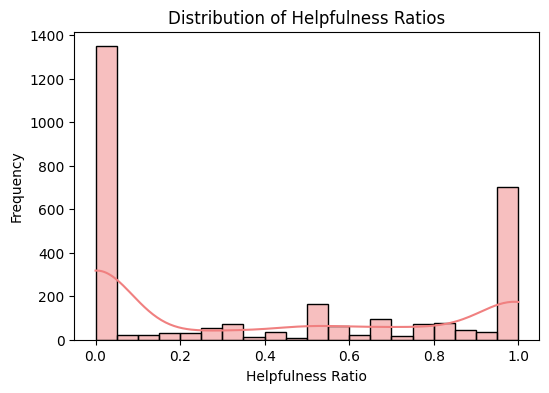

In [ ]:
#3. Distribution of Helpfulness Ratios
plt.figure(figsize=(6, 4))
sns.histplot(df_integrated['helpful_ratio'], bins=20, kde=True, color='lightcoral')
plt.title('Distribution of Helpfulness Ratios')
plt.xlabel('Helpfulness Ratio')
plt.ylabel('Frequency')
plt.show()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


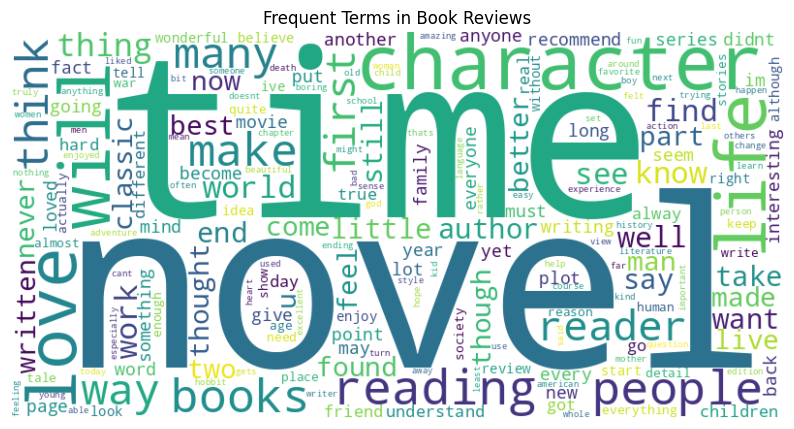

In [ ]:
#4. Word Clouds / Frequent Terms
nltk.download('vader_lexicon')
text_for_wordcloud = " ".join(review for review in df_integrated['clean_review'])
stopwords = set(STOPWORDS)
#Add common book-related stopwords that might not add much value
stopwords.update(["book", "read", "story", "like", "just", "great", "good", "one", "get", "really", "much", "dont", "even"])

wordcloud = WordCloud(stopwords=stopwords, background_color="white", width=800, height=400).generate(text_for_wordcloud)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Frequent Terms in Book Reviews')
plt.show()

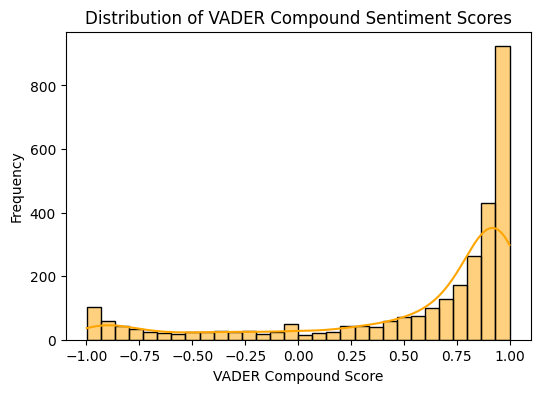


Correlation including VADER Compound Score

Pearson Correlation with VADER:


,star_rating,review_length,helpful_ratio,vader_compound_score
star_rating,1.000000,-0.054497,0.018749,0.271956
review_length,-0.054497,1.000000,0.279257,-0.039981
helpful_ratio,0.018749,0.279257,1.000000,0.034460
vader_compound_score,0.271956,-0.039981,0.034460,1.000000



Spearman Correlation with VADER:


,star_rating,review_length,helpful_ratio,vader_compound_score
star_rating,1.000000,-0.101163,-0.020307,0.187968
review_length,-0.101163,1.000000,0.361221,0.279468
helpful_ratio,-0.020307,0.361221,1.000000,0.130035
vader_compound_score,0.187968,0.279468,0.130035,1.000000


In [ ]:
#5. Basic Sentiment Polarity (VADER)
analyzer = SentimentIntensityAnalyzer()
df_integrated['vader_compound_score'] = df_integrated['clean_review'].apply(lambda text: analyzer.polarity_scores(text)['compound'])

plt.figure(figsize=(6, 4))
sns.histplot(df_integrated['vader_compound_score'], bins=30, kde=True, color='orange')
plt.title('Distribution of VADER Compound Sentiment Scores')
plt.xlabel('VADER Compound Score')
plt.ylabel('Frequency')
plt.show()

#Correlation with VADER scores
print('\nCorrelation including VADER Compound Score')
correlation_features = ['star_rating', 'review_length', 'helpful_ratio', 'vader_compound_score']
pearson_vader_corr = df_integrated[correlation_features].corr(method='pearson')
spearman_vader_corr = df_integrated[correlation_features].corr(method='spearman')

print('\nPearson Correlation with VADER:')
display(pearson_vader_corr)
print('\nSpearman Correlation with VADER:')
display(spearman_vader_corr)

**Interpretation:**
- **Sentiment Polarity & Bias:** The strong positive skew in star ratings and VADER scores suggests a "positivity bias." This confirms that star ratings alone are insufficient for ranking, as they fail to differentiate between "good" and "exceptional" books.

- **Quality Metrics:** Review length is a reliable proxy for helpfulness, whereas star ratings are not. This implies that users value depth and detail over the numerical score.

- **Validation of Text Analysis:** The positive correlation between VADER and star ratings validates that textual sentiment generally aligns with quantitative scores, justifying the move toward more granular analysis.


**Limitations:**

- **Data Skew & Sampling:** The heavy concentration of high ratings and the use of a dataset sample may limit the generalizability of these findings to the broader, more diverse Amazon marketplace.

## Hypothesis testing and validation

**Goal**: To determine if textual sentiment provides utility beyond star ratings by testing if "high-sentiment" reviews are more helpful than "low-sentiment" reviews within the same 4–5 star bracket.

**Method Justification**: A Mann-Whitney U test is used instead of a t-test because helpfulness ratio is not normally distributed. This non-parametric test compares whether one group tends to have higher values than another. Reviews are split into high-sentiment (VADER ≥ 0.5) and low-sentiment (VADER < 0.5) groups within the same star rating band to control for rating effects.

In [ ]:
#Filter for 4 and 5-star reviews
df_high_star = df_integrated[df_integrated['star_rating'].isin([4, 5])]

#Define high and low sentiment groups based on the median VADER compound score
median_vader_score = df_high_star['vader_compound_score'].median()
high_sentiment_reviews = df_high_star[df_high_star['vader_compound_score'] >= median_vader_score]
low_sentiment_reviews = df_high_star[df_high_star['vader_compound_score'] < median_vader_score]

#Extract helpfulness ratios for each group
helpfulness_high_sentiment = high_sentiment_reviews['helpful_ratio']
helpfulness_low_sentiment = low_sentiment_reviews['helpful_ratio']

# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(helpfulness_high_sentiment, helpfulness_low_sentiment, alternative='greater') #We use 'greater' as the alternative hypothesis to test if high-sentiment reviews are MORE helpful

print("Hypothesis Test: Sentiment vs Helpfulness (within 4-5 star reviews)")
print(f"H0: High-sentiment reviews are NOT more helpful than low-sentiment reviews")
print(f"H1: High-sentiment reviews ARE more helpful than low-sentiment reviews")
print(f"\nMann-Whitney U statistic: {stat:.2f}")
print(f"P-value: {p_value:.4f}")

Hypothesis Test: Sentiment vs Helpfulness (within 4-5 star reviews)
H0: High-sentiment reviews are NOT more helpful than low-sentiment reviews
H1: High-sentiment reviews ARE more helpful than low-sentiment reviews

Mann-Whitney U statistic: 810328.00
P-value: 0.0000


**Interpretation**:
- **Statistical Significance:** A p-value of 0.0000 rejects the null hypothesis ($H_0$). Hence, high-sentiment reviews are significantly more helpful than lower-sentiment reviews with same star ratings.
- **Practical Impact:** This validates textual sentiment (VADER) as a superior discriminator of review value compared to numerical ratings alone.

**Limitations:**
- **Positive Bias:** Findings are specific to high-rated reviews and may not apply to critical (1–2 star) contexts.

## Relationship and dependency analysis

**Goal:** To investigate whether star ratings, review length, and VADER sentiment polarity are statistically related to helpfulness ratio, and to each other.

**Method Justification:** Pearson correlation measures linear relationships between continuous variables, while Spearman correlation captures monotonic relationships without assuming normality. It is important here since star ratings are ordinal and helpfulness ratios may be skewed. Both are reported together for robustness.

In [ ]:
print('Pearson Correlation')
pearson_corr = df_integrated[['star_rating', 'review_length', 'helpful_ratio']].corr(method='pearson')
display(pearson_corr)

print('\nSpearman Correlation')
spearman_corr = df_integrated[['star_rating', 'review_length', 'helpful_ratio']].corr(method='spearman')
display(spearman_corr)

Pearson Correlation


,star_rating,review_length,helpful_ratio
star_rating,1.000000,-0.054497,0.018749
review_length,-0.054497,1.000000,0.279257
helpful_ratio,0.018749,0.279257,1.000000



Spearman Correlation


,star_rating,review_length,helpful_ratio
star_rating,1.000000,-0.101163,-0.020307
review_length,-0.101163,1.000000,0.361221
helpful_ratio,-0.020307,0.361221,1.000000


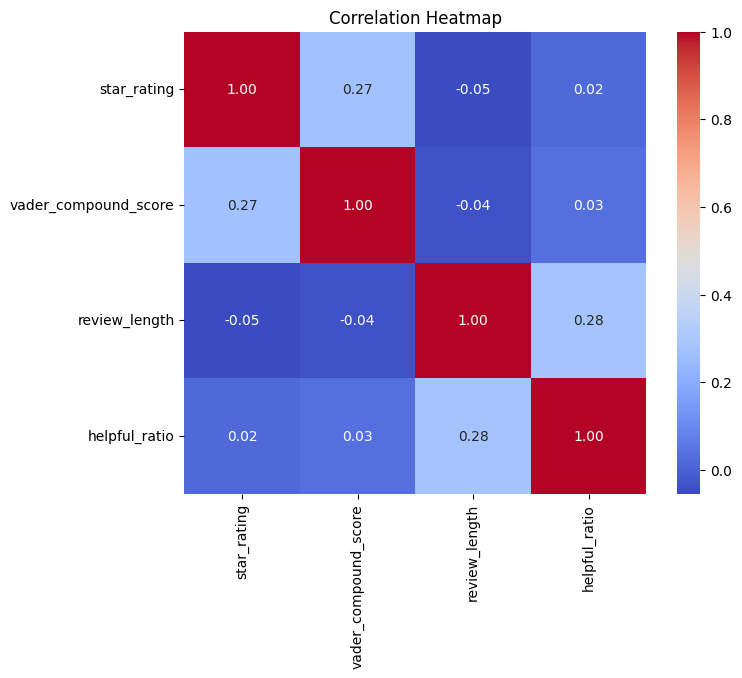

In [ ]:
# Correlation heatmap
corr_matrix = df_integrated[['star_rating', 'vader_compound_score', 'review_length', 'helpful_ratio']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.savefig("correlation_heatmap.png")
plt.show()

**Interpretation**
- **Length as a Proxy for Value:** The moderate positive correlation between review_length and helpful_ratio (Spearman: 0.361) suggests that users correlate detail with utility. The stronger Spearman coefficient indicates that while the relationship is not strictly linear, there is a consistent trend which is: as depth increases, perceived helpfulness increases too.

- **The Helpfulness-Rating Gap:** The near-zero correlation between star_rating and helpful_ratio confirms that sentiment polarity does not affect review quality. The same amount of value and attention given to a amazing 5-star recommendation is also given to a well-written and rationalised critique by users. This reflects that "helpfulness" is independent of "satisfaction".


**Limitations**
- **Lack of Qualitative Context:** Numerical data cannot distinguish between a long, rambling review and a long, insightful one. The analysis lacks the semantic "why" behind the user interaction.

## Recommendation System Design (Emotion Classification Model)

**Goal:** To train a multi-class classifier that predicts the dominant emotion expressed in a review, producing an emotion label and confidence score for every review in the dataset.

**Method Justification:** Comparing Logistic Regression, SVM, XGBoost, and DistilBERT to ensure selection of the best classifier. To ensure reliability, raw data is filtered for popular emotions and stratifically split. While traditional models use TF-IDF for efficiency, DistilBERT captures contextual nuance. Finally, emotion probabilities and star ratings are combined via percentile ranking, normalizing skewed data into a robust, discriminating composite score.

- **Input**: review text string ('clean_review' attribute of DS6)
- **Output:** 1 emotion label + probability score for each label*

*Only DistilBERT Classifier produces probility score for each label





**Additional justification for Cross-genre Ranking:**

- Since high ratings generally reflect universal user satisfaction rather than specific genre tones, applying a uniform ranking framework across the entire dataset is statistically justified.
- While genre-specific quality signals could offer deeper insights, extracting such nuance would require LLM-level contextual understanding, which falls outside the current project's scope.

### Identify and Filter Popular Emotions


Only emotions appearing in more than 5% of the GoEmotions dataset are identified, filtered, and mapped to integer labels.



---


**Justification for 5% frequency threshold:**
- A threshold is needed because DS6 GoEmotions has severe data imbalance among 27 emotions as shown in the data exploration stage. For example, neutral appears more than 60% of the times, while others like grief appear in under 0.5%. If we were to train a classifier on all the emotion, it would predict rare emotions only in extremely rare instances. This would cause misleading accuracy scores inflated by majority class dominance.



- We chose the 5% frequency threshold to ensure sufficient training samples per class.

  For example, Demszky et al. (2020) used 5% threshold to exclude unpopular emotions.
  
  Source: Demszky, D., Movshovitz-Attias, D., Ko, J., Cowen, A., Nemade, G., & Narang, S. (2020). GoEmotions: A Dataset of Fine-Grained Emotions. ACL 2020.


- This threshold resulted in 6 classes, which is manageable and reasonable minimum sample size for a text classifier to learn stable patterns. Lowering the threshold, we'll have fewer training class, thus we don't have enough emotion nuance. Raising the threshold, we'll have the same imbalance problem.



In [ ]:
emotion_counts = df_goemo[emotion_cols].sum()

#Calculate the significant_emotion_threshold
total_samples = len(df_goemo)
significant_emotion_threshold = 0.05 * total_samples

#Filter emotion_counts to identify significant_emotions_series
significant_emotions_series = emotion_counts[emotion_counts > significant_emotion_threshold]

#Convert the index to a list and store it as significant_emotions and target_names
significant_emotions = significant_emotions_series.index.tolist()
target_names = significant_emotions # Also assign to target_names as required
emotion_to_int = {emotion: i for i, emotion in enumerate(significant_emotions)}

# Convert the list of dictionaries into a new DataFrame called df_filtered
filtered_data_list = []
for index, row in df_goemo.iterrows():
    found_emotion = False
    for emotion in significant_emotions:
        if row[emotion] == 1:
            filtered_data_list.append({
                'text': row['text'],
                'emotion_label': emotion,
                'emotion_label_int': emotion_to_int[emotion]
            })
            found_emotion = True
            break

df_filtered = pd.DataFrame(filtered_data_list)

#Display
print(f"5% frequency threshold: {significant_emotion_threshold:.2f}")
print("\nSignificant Emotions:")
print(significant_emotions)
print("\nEmotion to Integer Mapping:")
print(emotion_to_int)
print("\nFirst 5 rows of df_filtered:")
display(df_filtered.head())
print(f"\nShape of df_filtered: {df_filtered.shape}")

5% frequency threshold: 3443.55

Significant Emotions:
['admiration', 'annoyance', 'approval', 'disapproval', 'gratitude', 'neutral']

Emotion to Integer Mapping:
{'admiration': 0, 'annoyance': 1, 'approval': 2, 'disapproval': 3, 'gratitude': 4, 'neutral': 5}

First 5 rows of df_filtered:


,text,emotion_label,emotion_label_int
0,"You do right, if you don't care then fuck 'em!",neutral,5
1,"[NAME] was nowhere near them, he was by the Fa...",neutral,5
2,Right? Considering it’s such an important docu...,gratitude,4
3,"He isn't as big, but he's still quite popular....",disapproval,3
4,"I have, and now that you mention it, I think t...",neutral,5



Shape of df_filtered: (40339, 3)


**Sensitivity analysis**

This is a short sensitivity analysis exploring how outcomes shift under alternative thresholds (such as 3% or 10%) to validate the robustness of the results.

In [ ]:
#Threshold: 3%

emotion_counts = df_goemo[emotion_cols].sum()
total_samples = len(df_goemo)
significant_emotion_threshold = 0.03 * total_samples
significant_emotions_series = emotion_counts[emotion_counts > significant_emotion_threshold]
significant_emotions = significant_emotions_series.index.tolist()
target_names = significant_emotions
emotion_to_int = {emotion: i for i, emotion in enumerate(significant_emotions)}

filtered_data_list_3 = []
for index, row in df_goemo.iterrows():
    for emotion in significant_emotions:
        if row[emotion] == 1:
            filtered_data_list_3.append({
                'text': row['text'],
                'emotion_label': emotion,
                'emotion_label_int': emotion_to_int[emotion]
            })
            break # Assign only the first significant emotion found

df_filtered = pd.DataFrame(filtered_data_list_3)

print(f"3% frequency threshold: {significant_emotion_threshold:.2f}")
print(f"\nSignificant Emotions: {significant_emotions}")
print(f"\nEmotion to Integer Mapping: {emotion_to_int}")
print(f"\nShape of df_filtered: {df_filtered.shape}")
print("\nFirst 5 rows of df_filtered:")
display(df_filtered.head())

3% frequency threshold: 2066.13

Significant Emotions: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'confusion', 'curiosity', 'disappointment', 'disapproval', 'gratitude', 'joy', 'love', 'optimism', 'realization', 'sadness', 'neutral']

Emotion to Integer Mapping: {'admiration': 0, 'amusement': 1, 'anger': 2, 'annoyance': 3, 'approval': 4, 'confusion': 5, 'curiosity': 6, 'disappointment': 7, 'disapproval': 8, 'gratitude': 9, 'joy': 10, 'love': 11, 'optimism': 12, 'realization': 13, 'sadness': 14, 'neutral': 15}

Shape of df_filtered: (61021, 3)

First 5 rows of df_filtered:


,text,emotion_label,emotion_label_int
0,That game hurt.,sadness,14
1,"You do right, if you don't care then fuck 'em!",neutral,15
2,Man I love reddit.,love,11
3,"[NAME] was nowhere near them, he was by the Fa...",neutral,15
4,Right? Considering it’s such an important docu...,gratitude,9


In [ ]:
#Threshold: 10%

emotion_counts = df_goemo[emotion_cols].sum()
total_samples = len(df_goemo)
significant_emotion_threshold = 0.1 * total_samples
significant_emotions_series = emotion_counts[emotion_counts > significant_emotion_threshold]
significant_emotions = significant_emotions_series.index.tolist()
target_names = significant_emotions
emotion_to_int = {emotion: i for i, emotion in enumerate(significant_emotions)}

filtered_data_list_10 = []
for index, row in df_goemo.iterrows():
    for emotion in significant_emotions:
        if row[emotion] == 1:
            filtered_data_list_10.append({
                'text': row['text'],
                'emotion_label': emotion,
                'emotion_label_int': emotion_to_int[emotion]
            })
            break # Assign only the first significant emotion found

df_filtered = pd.DataFrame(filtered_data_list_10)

print(f"10% frequency threshold: {significant_emotion_threshold:.2f}")
print(f"\nSignificant Emotions: {significant_emotions}")
print(f"\nEmotion to Integer Mapping: {emotion_to_int}")
print(f"\nShape of df_filtered: {df_filtered.shape}")
print("\nFirst 5 rows of df_filtered:")
display(df_filtered.head())

10% frequency threshold: 6887.10

Significant Emotions: ['neutral']

Emotion to Integer Mapping: {'neutral': 0}

Shape of df_filtered: (18423, 3)

First 5 rows of df_filtered:


,text,emotion_label,emotion_label_int
0,"You do right, if you don't care then fuck 'em!",neutral,0
1,"[NAME] was nowhere near them, he was by the Fa...",neutral,0
2,"I have, and now that you mention it, I think t...",neutral,0
3,BUT IT'S HER TURN! /s,neutral,0
4,Build a wall? /jk,neutral,0


**Conclusion:**
At a 5% frequency threshold, six meaningful emotions are retained, striking a balance between the overly restrictive 10% threshold (which yields only "neutral") and the overly inclusive 2% threshold (which retains all 16 emotions). Therefore, 5% the most appropriate cutoff for modeling.

### Split Data into Training and Testing Sets




Text data (`X`) and corresponding labels (`y`) are split into 80/20 training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`).

In [ ]:
X = df_filtered['text']
y = df_filtered['emotion_label_int']

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (40339,)
Shape of y: (40339,)


In [ ]:
# Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Verify the split ratio
total_samples = len(X_train) + len(X_test)
train_ratio = len(X_train) / total_samples
test_ratio = len(X_test) / total_samples

print(f"\nTraining set ratio: {train_ratio:.2f}")
print(f"Testing set ratio: {test_ratio:.2f}")

Shape of X_train: (32271,)
Shape of X_test: (8068,)
Shape of y_train: (32271,)
Shape of y_test: (8068,)

Training set ratio: 0.80
Testing set ratio: 0.20


### Vectorize Text Data




Vectorize the text data (X_train, X_test) into numerical features using TfidfVectorizer, leveraging the num_features variable for max_features.

In [ ]:
# Initialize TfidfVectorizer with max_features from the previously defined num_features
tfidf_vectorizer = TfidfVectorizer(max_features=num_features)

# Fit the vectorizer on X_train (the training text data)
tfidf_vectorizer.fit(X_train)

# Transform both X_train and X_test into numerical feature vectors
X_train_vectorized = tfidf_vectorizer.transform(X_train)
X_test_vectorized = tfidf_vectorizer.transform(X_test)

print("Text data vectorized successfully.")
print(f"Shape of X_train_vectorized: {X_train_vectorized.shape}")
print(f"Shape of X_test_vectorized: {X_test_vectorized.shape}")

Text data vectorized successfully.
Shape of X_train_vectorized: (32271, 20000)
Shape of X_test_vectorized: (8068, 20000)


### Train Logistic Regression Model


**Description for Logistic Regression:** (Statistical) Predicts class probabilities using a linear decision boundary over TF-IDF features


* We chose Logistic Regression as the simplest baseline, because it isfast to train, interpretable, and well-established for text classification with TF-IDF features. Sets the minimum performance bar.

**Actions:** We initialize a Logistic Regression classifier, train it on the vectorized training data (X_train_vectorized, y_train), and make predictions on the vectorized test data (X_test_vectorized). Evaluate the model with accuracy.


In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs') #Set max_iter for convergence, random_state for reproducibility, and solver for multi-class classification.

print("Training Logistic Regression model...")
lr_model.fit(X_train_vectorized, y_train)
print("Logistic Regression model trained.")

y_pred_lr = lr_model.predict(X_test_vectorized)

#Calculate the accuracy
overall_accuracy = accuracy_score(y_test, y_pred_lr)

#Display the results
print(f"\nLogistic Regression Model Performance:")
print(f"Accuracy: {overall_accuracy:.4f}")

Training Logistic Regression model...
Logistic Regression model trained.

Logistic Regression Model Performance:
Accuracy: 0.5839


### Train Support Vector Machine (SVM)




**Description for LinearSVC:** (Statistical) Finds the optimal hyperplane that maximizes margin between emotion classes in feature space
* We chose LinearSVC because SVMs usually outperform logistic regression on high-dimensional sparse text features. Included to test whether a stronger linear classifier improves over the baseline.

**Actions:** We initialize a LinearSVC classifier, train it on the vectorized training data (X_train_vectorized, y_train), make predictions on the vectorized test data (X_test_vectorized), and then calculate and display the accuracy.

In [ ]:
svm_model = LinearSVC(random_state=42, dual=True) # Set dual=True for older scikit-learn versions to avoid future warning

print("Training LinearSVC model...")
svm_model.fit(X_train_vectorized, y_train)
print("LinearSVC model trained.")

y_pred_svm = svm_model.predict(X_test_vectorized)

#Calculate the accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)

#Display the results
print(f"\nLinearSVC Model Performance:")
print(f"Accuracy: {accuracy_svm:.4f}")

Training LinearSVC model...
LinearSVC model trained.

LinearSVC Model Performance:
Accuracy: 0.5512


### Train XGBoost Classifier

**Description for XGBoost:** (Ensemble) Combines multiple decision trees sequentially, each correcting errors of the previous
* We chose XGBoost to test whether a non-linear ensemble method captures patterns that linear models miss in TF-IDF feature space. Represents the ceiling of traditional ML approaches.

**Actions:** Initialize an XGBClassifier, train it on the vectorized training data (X_train_vectorized, y_train), make predictions on the vectorized test data (X_test_vectorized), and then calculate and display the accuracy.

In [ ]:
xgb_model = XGBClassifier(objective='multi:softmax', num_class=len(target_names), random_state=42, eval_metric='mlogloss')

print("Training XGBoost model...")
xgb_model.fit(X_train_vectorized, y_train)
print("XGBoost model trained.")

y_pred_xgb = xgb_model.predict(X_test_vectorized)

#Calculate accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

#Display the results
print(f"\nXGBoost Model Performance:")
print(f"Accuracy: {accuracy_xgb:.4f}")

Training XGBoost model...
XGBoost model trained.

XGBoost Model Performance:
Accuracy: 0.5845


### Initialize DistilBERT Classifier ([pre-trained model](https://huggingface.co/bhadresh-savani/distilbert-base-uncased-emotion))

**Description for DistilBERT:** (Transformer) Contextual language model that reads full sentence meaning rather than word frequency counts
* We chose DistilBERT because transformer-based models understand word context and sentence meaning, unlike TF-IDF which treats text as a bag of words. Included to test whether contextual embeddings justify the added complexity over traditional ML.

**Actions:** We iInitialize the `text-classification` pipeline from the `transformers` library using the pre-trained model '[bhadresh-savani/distilbert-base-uncased-emotion](https://huggingface.co/bhadresh-savani/distilbert-base-uncased-emotion)'. Then, apply the emotion classifier to the X_train dataset. This will involve iterating through the text samples and collecting the predictions, calculating their accuracy.

In [ ]:
#Initialize the emotion classifier pipeline
emotion_classifier = pipeline("text-classification", model="bhadresh-savani/distilbert-base-uncased-emotion")

print("Emotion classifier pipeline initialized.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Emotion classifier pipeline initialized.


In [ ]:
X_test_predictions = []

#Iterate through each text in the X_test and predict
for text in X_test:
    prediction = emotion_classifier(text)
    X_test_predictions.append(prediction)

print(f"Total predictions made for X_test: {len(X_test_predictions)}")
print("The 6 emotion predictions for X_test:")
for i, pred in enumerate(X_test_predictions[:6]):
    print(f"Text {i+1}: {pred}")

Total predictions made for X_test: 8068
The 6 emotion predictions for X_test:
Text 1: [{'label': 'joy', 'score': 0.9302894473075867}]
Text 2: [{'label': 'anger', 'score': 0.591221809387207}]
Text 3: [{'label': 'joy', 'score': 0.9944724440574646}]
Text 4: [{'label': 'joy', 'score': 0.9965290427207947}]
Text 5: [{'label': 'love', 'score': 0.9858163595199585}]
Text 6: [{'label': 'love', 'score': 0.9758743643760681}]


In [ ]:
#Create a label_map based on your 'emotion_to_int' from previous steps
int_to_emotion = {v: k for k, v in emotion_to_int.items()}

#Convert y_test (integer labels) to string labels using the correct mapping
y_test_labels = [int_to_emotion.get(label_int, 'unknown').strip().lower() for label_int in y_test]

#Extract predicted labels from DistilBERT's output
predicted_labels = [pred[0]['label'].strip().lower() for pred in X_test_predictions]
min_len = min(len(y_test_labels), len(predicted_labels))
y_test_labels = y_test_labels[:min_len]
predicted_labels = predicted_labels[:min_len]

#Calculate the accuracy score
accuracy = accuracy_score(y_test_labels, predicted_labels)

print(f"Distilbert Classifier Performance:")
print(f"Accuracy: {accuracy:.4f}")

Distilbert Classifier Performance:
Accuracy: 0.8324


### Summary for Emotion Classification Model

Comparing four classification approaches, from traditional ML to pre-trained transformers, to identify the most accurate model for extracting emotion signals from book review text.

In [ ]:
model_names = ['Logistic Regression', 'LinearSVC', 'XGBoost', 'Distilbert Classifier']
accuracy_scores = [0.5839, 0.5512, 0.5845, 0.8324]

data = {
    'Model': model_names,
    'Accuracy': accuracy_scores
}

df_model_performance = pd.DataFrame(data)

print("DataFrame 'df_model_performance' created successfully.")
display(df_model_performance)

DataFrame 'df_model_performance' created successfully.


,Model,Accuracy
0,Logistic Regression,0.5839
1,LinearSVC,0.5512
2,XGBoost,0.5845
3,Distilbert Classifier,0.8324


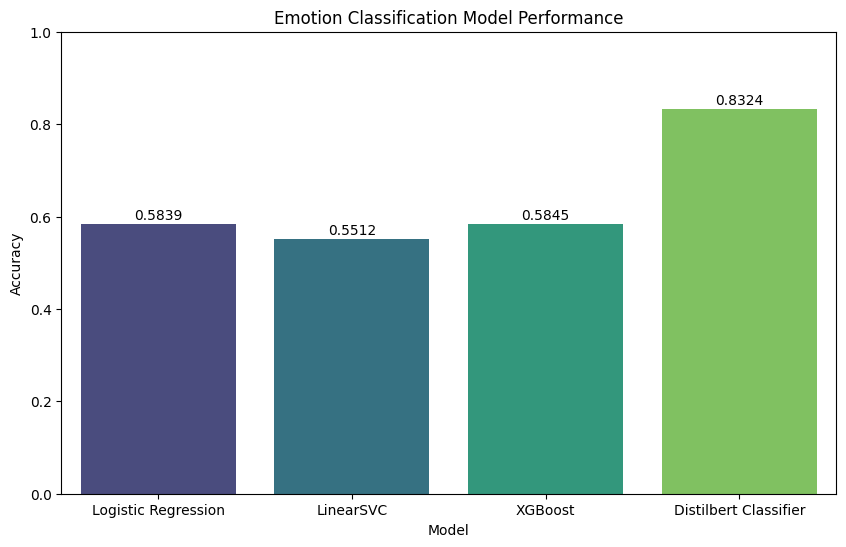

Model performance bar chart generated successfully.


In [ ]:
#Displaying a visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=df_model_performance, hue='Model', palette='viridis', legend=False)
plt.title('Emotion Classification Model Performance')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1

#Annotate bars with accuracy values
for index, row in df_model_performance.iterrows():
    plt.text(index, row['Accuracy'] + 0.01, f'{row['Accuracy']:.4f}', color='black', ha="center")

plt.show()

print("Model performance bar chart generated successfully.")

### Applying to the Reviews (integrated_dataset)

Having identified DistilBERT as the highest-performing model, we apply it to the full Amazon reviews dataset to extract emotion probability scores for each review. This inference step operates on real book review language, producing the per-review emotion signals that feed directly into the composite ranking formula.



**Additional supporting reasons to choose DistilBERT:**


- Returns full probability distribution across all 6 emotions per review, not just a single predicted label. This enables a nuanced emotion score rather than a binary positive/negative classification.
- Pre-trained on large text corpora means it generalises to book review vocabulary without needing retraining on Amazon data (faster, more effective).
- Handles variable review lengths and informal language better than TF-IDF, which is critical since Amazon reviews range from 1 sentence to several paragraphs.

In [ ]:
#Apply the classifier to the batch and extend the all_emotion_predictions list with the results
emotion_classifier = pipeline("text-classification", model="bhadresh-savani/distilbert-base-uncased-emotion", return_all_scores=True)
print("Emotion classifier pipeline redefined with return_all_scores=True.")

all_emotion_predictions = []

batch_size = 64
reviews = df_integrated['clean_review'].tolist()

for i in range(0, len(reviews), batch_size):
    batch = reviews[i:i + batch_size]
    batch_predictions = emotion_classifier(batch, truncation=True)
    all_emotion_predictions.extend(batch_predictions)

print(f"Total reviews processed: {len(reviews)}")
print(f"Total predictions stored: {len(all_emotion_predictions)}")
print("First 3 predictions:")
for i, pred in enumerate(all_emotion_predictions[:3]):
    print(f"Review {i+1}: {pred}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Emotion classifier pipeline redefined with return_all_scores=True.
Total reviews processed: 2926
Total predictions stored: 2926
First 3 predictions:
Review 1: {'label': 'sadness', 'score': 0.7701485753059387}
Review 2: {'label': 'joy', 'score': 0.9930041432380676}
Review 3: {'label': 'joy', 'score': 0.7209672331809998}


**EMOTION SCORE PER REVIEW**


> **emotion_score** = (admiration + approval + gratitude) − (annoyance + disapproval + neutral*)

*Because neutral reviews often function as "weak positives" that fail to provide strong endorsement, they are treated as negative signals to ensure the ranking favors high-conviction emotional praise.

Each review gets 6 probability scores from DistilBERT summing to 1.0. We calculate using these probability scoress.
Within the range (-1, 1), the higher emotion_score, the stronger positive review.



In [ ]:
emotions_to_extract = ['admiration', 'annoyance', 'approval', 'disapproval', 'gratitude', 'neutral']

for emotion in emotions_to_extract:
    df_integrated[f'{emotion}_score'] = 0.0

for i, prediction_dict in enumerate(all_emotion_predictions):
    if isinstance(prediction_dict, dict) and 'label' in prediction_dict and 'score' in prediction_dict:
        label = prediction_dict['label']
        score = prediction_dict['score']
        if label in emotions_to_extract:
            df_integrated.loc[i, f'{label}_score'] = score

# Calculate the emotion_score
df_integrated['emotion_score'] = (
    df_integrated['admiration_score'] +
    df_integrated['approval_score'] +
    df_integrated['gratitude_score'] -
    df_integrated['annoyance_score'] -
    df_integrated['disapproval_score'] -
    df_integrated['neutral_score']
)

**COMPOSITE SCORE PER REVIEW**

A composite score is a single unified metric that combines two signals — star rating and emotion score. Converting both signals to percentile ranks puts them on the same 0–1 scale spread signals always produces a bell-curve shaped result, according to the Central Limit Theorem.

> **star_rank** = star_rating.rank(pct=True)

> **emotion_rank** = emotion_score.rank(pct=True)

> **composite_score** = star_rank * 0.4 + emotion_rank * 0.6


**Justification for the weightage** (0.4, 0.6):
- Star ratings are heavily skewed, with 61% of reviews are 5-star, meaning star_rank alone pulls the composite score toward the high end. To counteract this, emotion_rank is given more weight (0.6) to pull the distribution back toward center.
- Different weight combinations were tested by comparing the resulting score distributions visually, as we experiemented during this project. The 0.4/0.6 split produced the most symmetric, bell-shaped distribution, giving emotion enough influence to correct the star rating skew without completely overriding the explicit rating signal.






**PER-BOOK AGGREGATION**

 Grouping by book ID and averaging the composite score across all reviews smooths out outliers and produces one stable, representative ranking score per book. Books with more reviews get a more reliable final score.

In [ ]:
#Calculate star_rank using percentile ranking
df_integrated['star_rank'] = df_integrated['star_rating'].rank(pct=True)

#Calculate emotion_rank using percentile ranking
df_integrated['emotion_rank'] = df_integrated['emotion_score'].rank(pct=True)

#Create a composite_score as the average of star_rank and emotion_rank
df_integrated['composite_score'] = df_integrated['star_rank']*0.4 + df_integrated['emotion_rank']*0.6

display(df_integrated[['star_rating', 'star_rank', 'emotion_score', 'emotion_rank', 'composite_score']].head())

,star_rating,star_rank,emotion_score,emotion_rank,composite_score
0,5,0.683869,0.0,0.500171,0.57365
1,5,0.683869,0.0,0.500171,0.57365
2,5,0.683869,0.0,0.500171,0.57365
3,5,0.683869,0.0,0.500171,0.57365
4,5,0.683869,0.0,0.500171,0.57365


In [ ]:
#Calculate average composite score
df_book_ranking = df_integrated.groupby('Title_review')['composite_score'].mean().reset_index()
df_book_ranking = df_book_ranking.rename(columns={'composite_score': 'avg_composite_score'})

#Display sample composite scores (for top 10 books)
df_book_ranking_sorted = df_book_ranking.sort_values(by='avg_composite_score', ascending=False)

print("Top 10 books based on average composite score:")
display(df_book_ranking_sorted.head(10))

Top 10 books based on average composite score:


,Title_review,avg_composite_score
127,FEAR AND LOATHING IN LAS VEGAS a Savage Journe...,0.57365
517,Up from slavery: An autobiography,0.57365
30,"A Tree Grows in Brooklyn by Smith, Betty",0.57365
17,A Gathering of Spies,0.57365
21,A Princess of Mars,0.57365
518,Valhalla Rising (Dirk Pitt Adventure),0.57365
498,Time and Chance,0.57365
500,To Kill A Mockingbird,0.57365
461,The Secret Garden (Worlds Classics),0.57365
478,The Wonderful Wizard Of Oz,0.57365


### Visualizing Average Composite Scores for Books

We use Kernel Density Estimation (KDE) plots rather than histograms because the data consists of continuous values. KDE provides a smooth, non-parametric curve that more accurately represents the underlying distribution by eliminating the arbitrary binning bias associated with histograms.

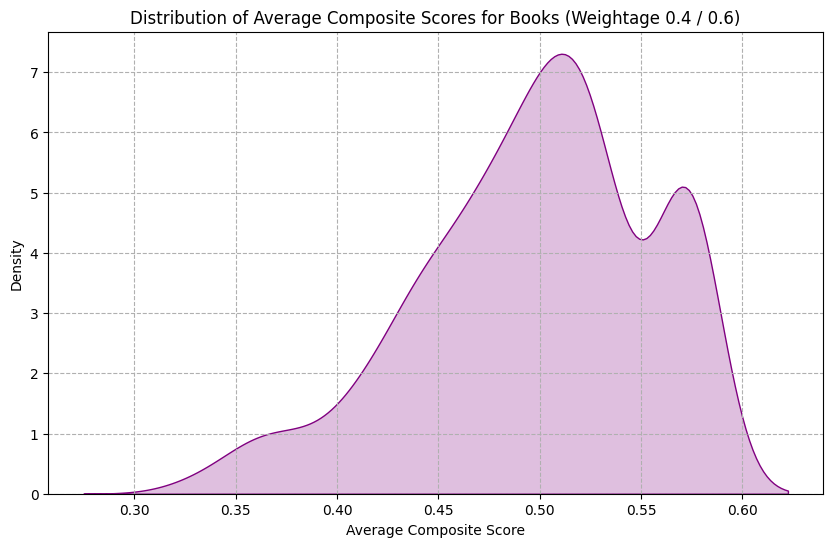

In [ ]:
#Distribution of Average Composite Scores for Books (Weightage 0.4 / 0.6) ==> SELECTED
plt.figure(figsize=(10, 6))
sns.kdeplot(df_book_ranking['avg_composite_score'], fill=True, color='purple')
plt.title('Distribution of Average Composite Scores for Books (Weightage 0.4 / 0.6)')
plt.xlabel('Average Composite Score')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=1)
plt.show()

**Sensitivity analysis**

This is the analysis to demonstrate that the 0.4/0.6 weighting produces more robust results than the equal 0.5/0.5 split.

Visualization of the Distribution of Average Composite Scores for Books **(Weightage 0.5 / 0.5)** ==> **Not selected** because of suboptimal normalization


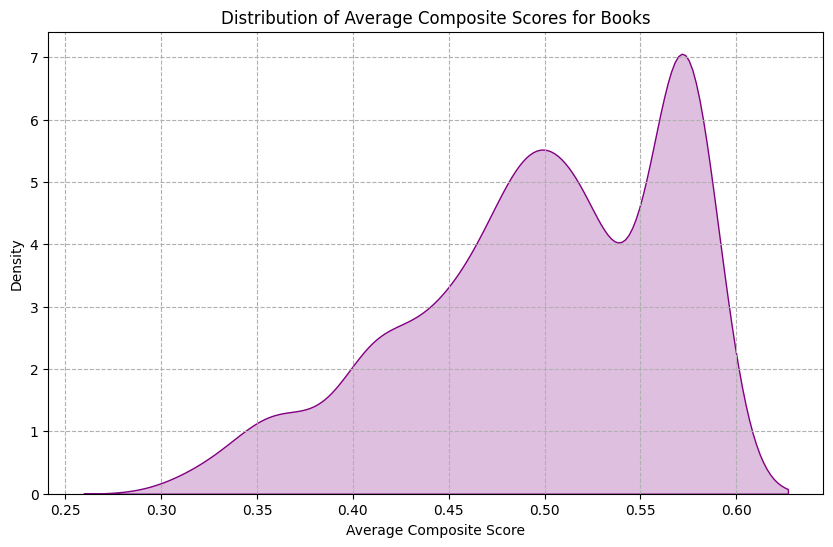

### **Interpretation:**

- Transformer Superiority: DistilBERT's 83.24% accuracy over traditional models (<60%) (as shown in above graphs) validates that contextual embeddings are important for extracting the nuanced emotions and sentiments from book reviews.


- Granular Scoring: Moving beyond binary sentiment to a weighted emotion_score (contrasting admiration/approval vs. annoyance/disapproval) provides a more sophisticated metric for reader engagement.

- Normalization of Bias: The 0.4/0.6 weighted composite_score successfully transforms skewed star ratings into a bell-shaped distribution. This allows for a clearer distinctions between simply good and outstanding books.

### **Limitations:**
- Label Simplification: Flattening multi-label emotions into a single labels during training helps remove complex, multi-layered reviewer sentiments. But, this may lead to a loss of information on emotions and sentiments from the reviews.

- Contextual Blind Spots: Despite its strengths, the model may struggle with nuanced literary sarcasm, abstract critiques, or emotional expectations that vary across different genres.

## System Comparison & Evaluation

**Goal:** To quantitatively and qualitatively validate that the Composite Scoring System provides a more granular, nuanced, and less biased evaluation of book quality compared to traditional star ratings.

**Method Justification:**

- **Distribution Comparison:** We utilized countplots for discrete star ratings and KDE plots for continuous composite scores. This highlights the "positivity bias" (skewed 4–5 stars) versus the normalized, bell-shaped distribution of the new system.

- **Linear Transformation:** Composite scores were mapped to a 1–5 scale for direct visual overlay against original ratings, confirming how the new system spreads out evaluations.

- **Spearman Rank Correlation:** This non-parametric test was chosen to measure the monotonic relationship between the two ranking systems without assuming linearity or normal distribution.

- **Differentiation Metrics:** We calculated Mean Absolute Displacement (MAD) to quantify the magnitude of reordering and the Percentage of Ties Broken to prove the system’s superior granular precision.

### Comparison of Original Star Ratings and Transformed Composite Scores

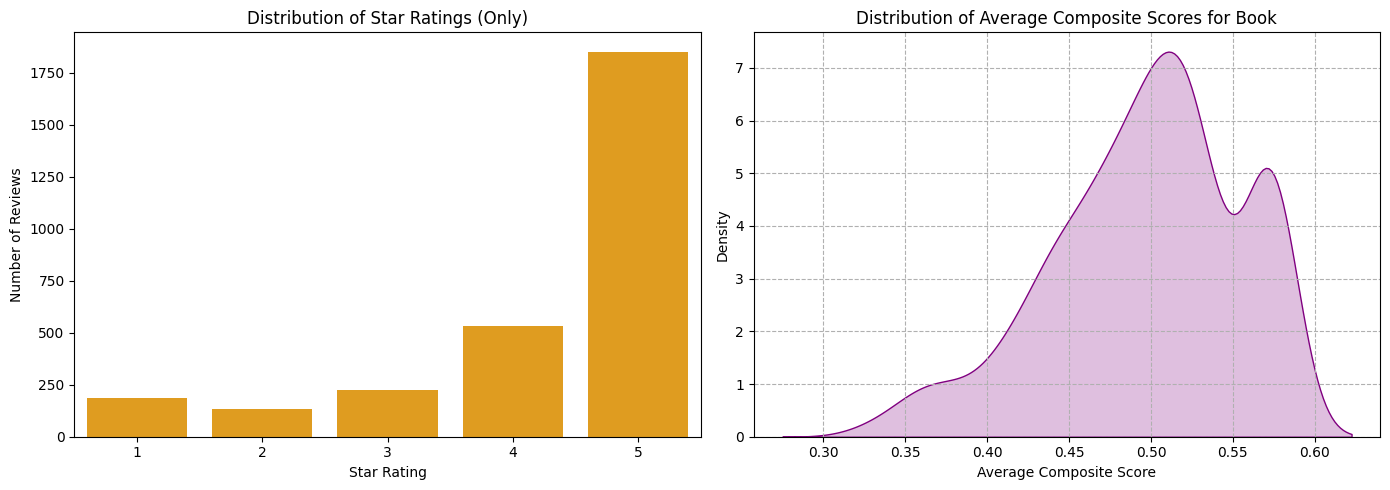

In [ ]:
#Comparing Distribution of Star Ratings and Distribution of Average Composite Scores Side by Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # 1 row, 2 columns

#Plot 1: Distribution of Star Ratings Only
sns.countplot(x='star_rating', data=df_integrated, color="orange", ax=axes[0])
axes[0].set_title('Distribution of Star Ratings (Only)')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')

#Plot 2: Distribution of Average Composite Scores for Books (Weightage 0.4 / 0.6)
sns.kdeplot(df_book_ranking['avg_composite_score'], fill=True, color='purple', ax=axes[1])
axes[1].set_title('Distribution of Average Composite Scores for Book')
axes[1].set_xlabel('Average Composite Score')
axes[1].set_ylabel('Density')
axes[1].grid(True, linestyle='--', alpha=1)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

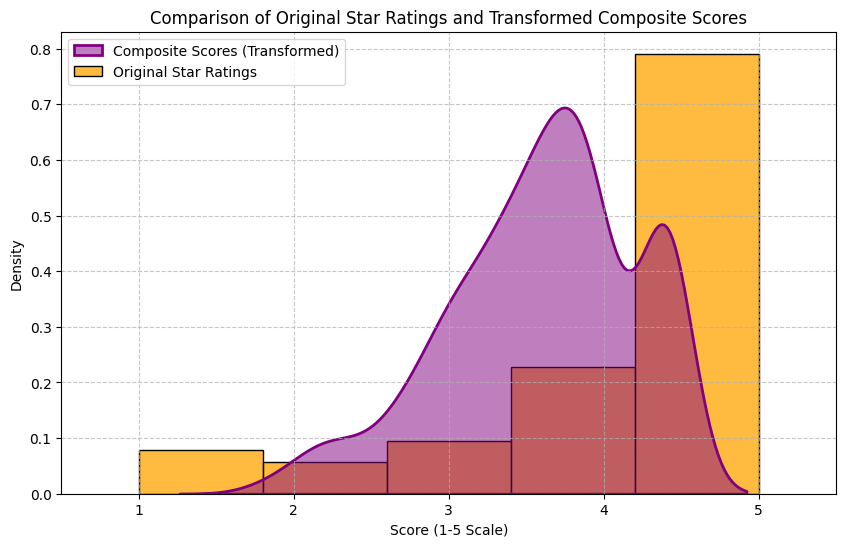

In [ ]:
min_star, max_star = 1, 5
min_composite, max_composite = 0.25, 0.63 #Define the min/max for composite scores (from previous analysis)

# Transform the composite scores to the 1-5 star rating range
df_book_ranking['transformed_composite_score'] = (
    (df_book_ranking['avg_composite_score'] - min_composite) /
    (max_composite - min_composite) *
    (max_star - min_star)
) + min_star

plt.figure(figsize=(10, 6))
sns.histplot(df_integrated['star_rating'], bins=5, stat='density', color='orange', label='Original Star Ratings')

# Plot the KDE of transformed composite scores
sns.kdeplot(df_book_ranking['transformed_composite_score'], fill=True, color='purple', alpha=0.5, label='Composite Scores (Transformed)', linewidth=2)

plt.title('Comparison of Original Star Ratings and Transformed Composite Scores')
plt.xlabel('Score (1-5 Scale)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0.5, 5.5) # Set x-axis limits to clearly show 1-5 star range
plt.show()

In [ ]:
#Examples of books with the most significant rank changes

df_baseline_ranking = df_integrated.groupby('Title_review')['star_rating'].mean().reset_index()
df_baseline_ranking = df_baseline_ranking.rename(columns={'star_rating': 'avg_star_rating'})

df_comparison = pd.merge(df_baseline_ranking, df_book_ranking, on='Title_review', how='inner')

#Calculate ranks for both systems
df_comparison['star_rank'] = df_comparison['avg_star_rating'].rank(ascending=False)
df_comparison['composite_rank'] = df_comparison['avg_composite_score'].rank(ascending=False)

df_comparison['rank_difference'] = df_comparison['star_rank'] - df_comparison['composite_rank']
df_comparison['absolute_rank_difference'] = abs(df_comparison['star_rank'] - df_comparison['composite_rank'])

df_top_10_rank_changes = df_comparison.sort_values(by='absolute_rank_difference', ascending=False).head(10)

# Merge df_top_10_rank_changes with df_integrated to get the clean_review text
df_reviews_for_top_changes = pd.merge(
    df_top_10_rank_changes[['Title_review', 'star_rank', 'composite_rank', 'rank_difference']],
    df_integrated[['Title_review', 'clean_review']],
    on='Title_review',
    how='left'
)

# Display the reviews, potentially grouping them by title for readability if multiple reviews per book
display(df_reviews_for_top_changes)

,Title_review,star_rank,composite_rank,rank_difference,clean_review
0,Love You Forever,343.0,175.0,168.0,ill love you forever ill like you for always a...
1,Love You Forever,343.0,175.0,168.0,our family loves this book very sweet story ev...
2,Love You Forever,343.0,175.0,168.0,this is one of my favorite childrens books i u...
3,Love You Forever,343.0,175.0,168.0,love you forever by sheila mcgraw and robert n...
4,Love You Forever,343.0,175.0,168.0,i can understand a lot of the positive comment...
5,Autobiography of a Yogi,386.0,253.0,133.0,this is such a great book i recommend it to ev...
6,Autobiography of a Yogi,386.0,253.0,133.0,this is truly one of the great spiritual reads...
7,Autobiography of a Yogi,386.0,253.0,133.0,several years ago i was introduced to yoganand...
8,Autobiography of a Yogi,386.0,253.0,133.0,books that i would recommend over this one i a...
9,Darkfever (Fever Series),386.0,253.0,133.0,this book was neither thrilling nor romantic i...


### Evaluate Ranking Differences

Spearman rank correlation between systems: 0.954 (p=0.0000)




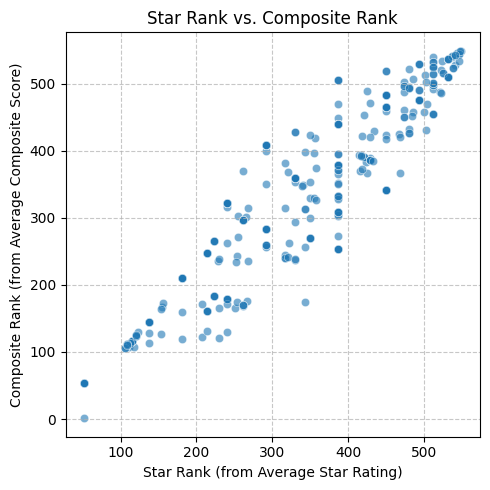

In [ ]:
#Correlation between Star Rank and Composite Rank
df_baseline_ranking = df_integrated.groupby('Title_review')['star_rating'].mean().reset_index()
df_baseline_ranking = df_baseline_ranking.rename(columns={'star_rating': 'avg_star_rating'})

df_comparison = pd.merge(df_baseline_ranking, df_book_ranking, on='Title_review', how='inner')

#Calculate ranks for both systems
df_comparison['star_rank'] = df_comparison['avg_star_rating'].rank(ascending=False)
df_comparison['composite_rank'] = df_comparison['avg_composite_score'].rank(ascending=False)

#Calculate Spearman rank correlation
rho, p = spearmanr(df_comparison['star_rank'], df_comparison['composite_rank'])
print(f"Spearman rank correlation between systems: {rho:.3f} (p={p:.4f})\n\n")

#Scatter plot of Star Rank vs. Composite Rank
plt.figure(figsize=(5,5))
sns.scatterplot(x='star_rank', y='composite_rank', data=df_comparison, alpha=0.6)
plt.title('Star Rank vs. Composite Rank')
plt.xlabel('Star Rank (from Average Star Rating)')
plt.ylabel('Composite Rank (from Average Composite Score)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

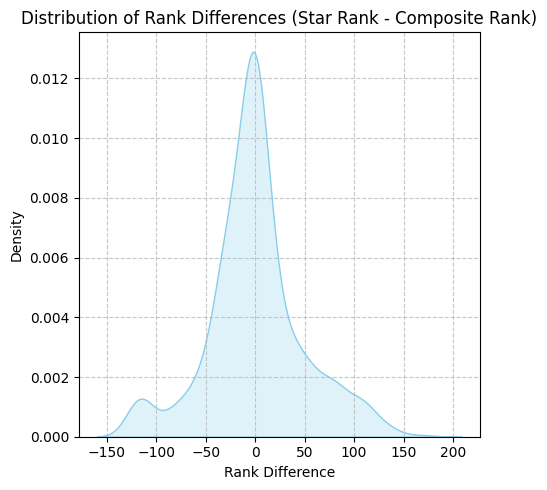

,avg_star_rating,avg_composite_score,normalized_composite_score,transformed_composite_score,star_rank,composite_rank,rank_difference,percentage_rank_change,absolute_rank_difference
count,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000
mean,4.249583,0.497079,0.650209,3.600835,275.000000,275.000000,0.000000,-1.221596,32.765027
std,0.680862,0.057434,0.151142,0.604568,157.864481,158.027471,48.061415,16.148398,35.133938
min,1.500000,0.323616,0.193726,1.774904,52.500000,1.000000,-119.000000,-41.762452,0.000000
25%,4.000000,0.464969,0.565709,3.262834,138.000000,145.000000,-28.000000,-8.774584,4.500000
50%,4.333333,0.502062,0.663321,3.653284,292.000000,283.500000,-0.500000,-0.952381,24.000000
75%,4.750000,0.532895,0.744460,3.977839,386.000000,408.500000,17.500000,3.954802,52.500000
max,5.000000,0.573650,0.851711,4.406842,549.000000,549.000000,168.000000,98.095238,168.000000


In [ ]:
#Visualize The Value of Rank Differences
df_comparison['rank_difference'] = df_comparison['star_rank'] - df_comparison['composite_rank']
plt.figure(figsize=(5, 5))
sns.kdeplot(df_comparison['rank_difference'], fill=True, color='skyblue')
plt.title('Distribution of Rank Differences (Star Rank - Composite Rank)')
plt.xlabel('Rank Difference')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(df_comparison.describe())

In [ ]:
#Calculate the Percentage of Rank Changes
df_comparison['rank_difference'] = df_comparison['star_rank'] - df_comparison['composite_rank']
non_zero_rank_changes = df_comparison[df_comparison['rank_difference'] != 0]

total_books = len(df_integrated.groupby('Title_review'))
books_with_change = len(non_zero_rank_changes)
ratio_with_change = (books_with_change / total_books) * 100

print(f"Number of books with non-zero rank change: {books_with_change}")
print(f"Total number of books: {total_books}")
print(f"Ratio of books with non-zero rank change: {ratio_with_change:.2f}%")

Number of books with non-zero rank change: 545
Total number of books: 549
Ratio of books with non-zero rank change: 99.27%


In [ ]:
#Calculate Mean Absolute Displacement (MAD)
df_comparison['absolute_rank_difference'] = abs(df_comparison['star_rank'] - df_comparison['composite_rank'])
mad = df_comparison['absolute_rank_difference'].mean()
print(f"Mean Absolute Displacement (MAD): {mad:.2f}")

#Calculate Percentage of 'Ties Broken'
unique_star_ranks = df_comparison['star_rank'].nunique()
total_books = len(df_comparison)
original_tied_books_count = total_books - unique_star_ranks
percentage_ties_broken = ((total_books - unique_star_ranks) / total_books) * 100 if total_books > 0 else 0
print(f"Percentage of 'Ties Broken': {percentage_ties_broken:.2f}%")

Mean Absolute Displacement (MAD): 32.77
Percentage of 'Ties Broken': 85.06%


### **Key Findings:**

- **Bias Mitigation:** The composite scoring system that we used helped to transform the heavily skewed rating from Dataset 1 into a balanced distribution. This ensured a more uniform differentiation across the entire spectrum.

- **Significant Reordering:** Despite a high Spearman correlation (**0.954**), **99.27% of books** underwent a rank change. This shows that the system is not unnecessary and obsolete. Instead, it actively re-evaluates almost every book title by basing it on the emotional depth extracted from the reviews.

- **Meaningful Shifts:** There is an average rank shift (MAD) of **32.77 positions**. This shows that the system causes significant changes to the leaderboard, highlighting books with high "emotional conviction" over those with "hollow and emotionally insignificant" 5-star ratings.

- **Superior Granularity:** The system broke **85.06% of existing rank ties**. Hence, the composite score provides the fine-grained distinction needed for accurate and high-quality recommendations.


### **Limitations:**
- **Absence of Ground Truth**: Without a clear benchmark (such as expert editorial rankings or long-term sales data), we are unable to conclusively verify the composite ranking system to prove that it provides greater granularity and effectively resolves ties.



# **Presentation of main results (Share)**

## **Stakeholders:**

The results will be presented to our primary stakeholders, Amazon recommendation system engineers, book sellers and customers. For Amazon, this would mean being able to improve recommendation algorithms and boosting their user engagement which would likely bring in more profits and an increased customer satisfaction. For sellers, they will better understand how readers perceive their books and change their marketing and advertising strategies likewise. Finally, customers will be able to make more confident decisions as they will be equipped with information beyond star ratings.


## **Visualization / Summary of Findings:**

One of the main problems identified was that the star ratings were heavily skewed (majority 4-5) stars. Moreover, ratings alone failed to distinguish truly meaningful reviews. As shown in the first graph, the original rating distribution is concentrated at the higher end, indicating strong positive bias. To counteract this problem, we performed sentiment and emotion extraction using DistilBERT. We also ensure that the composite scoring system used was 40% star rating and 60% emotion score which would correct the star rating skew without completely overriding the explicit rating signal.

For instance, the book titled "Love you Forever" moved significantly up in the rankings with a rank difference value of 168.  While it had a similar star rating to other books, its reviews contained strong emotional signals such as admiration, gratitude, and joy, correlating to genuine reader engagement.


These examples demonstrate how the composite scoring system differentiates between surface-level ratings and deeper emotional responses, leading to more informative rankings.

Despite a high Spearman correlation of 0.954 between the original and new rankings, 99.27% of books experienced a rank change, with an average shift of 32.77 positions. This demonstrates that the system is not redundant, but actively re-evaluates books based on emotional depth. As further supported by the second graph, rank differences are widely distributed, indicating meaningful reordering rather than minor adjustments.


**Narrative to Stakeholders:**

Our analysis showed that only relying on star ratings would lead to inflated and less meaningful book rankings. This is because many books have high star ratings despite maybe having poorer review qualities. By including the sentiment and emotion analysis, we are able to reveal the reader's true opinion rather than just depending on a numerical score. 2 books with the exact same ratings can now be distinguished based on its review. (Difference between weak generic praise and sincere appreciation). Moreover, the composite scoring system also produces more balanced and informative rankings allowing stakeholders to reap many benefits. In a nutshell, this recommendation system allows for the book ranking to be seen as a human-centered evaluation framework rather than a mere numerical rating.


# **Possible actions based on results (Act)**

Possible actions would include improving Amazon's recommendation system by integrating emotion based scoring into its ranking algorithm, which would ultimately lead to more meaningful and customized book recommendations.
Sellers can also rethink their marketing strategies with the efficient usage of these emotional feedback trends. This will allow them to have a deeper understanding of the customer's perspective and aim to meet their requirements. Lastly, customer experience can be improved by recommending books based on emotional alignment. This would allow them to find titles that match their interests closely

# **Final Reflection**

## **Considerations on Data Ethics:**


It is important to note that interpreting emotions is fundamentally subjective. This means that even minor classification lapses may change the original intent behind the user's review. Additionally, if the datasets are reused, proper attribution must be maintained to remain compliant with the data usage policies specified.


## **Considerations on Data Privacy and Security:**

 The datasets used consist of publicly available Amazon reviews, which reduces major privacy concerns, and no sensitive personal data is involved as the analysis is conducted at an aggregate level. However, user-generated content should still be handled responsibly to prevent misuse of opinions or unintended profiling of users.
